In [3]:
import csv
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import numpy as np
import os
import pandas as pd
import sklearn
import sys
import statsmodels.api as sm
import warnings
#from pingouin import ancova
#import pingouin as pg
from datetime import datetime, timedelta,date
warnings.filterwarnings('ignore')
from IPython.display import HTML
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False
pd.options.display.max_columns = 40
pd.options.display.min_rows = 20

In [5]:
subjects = pd.read_csv("../data/aim2_exwas_data_2024-June-11.csv")

# ROUND 1
## Relaxed exposome wide association (ExWAS) to find variables associated with asthma variables (crude analysis with no covariates) for all participants

The goal of this exploratory analysis is to identify exposures/risk factors associated with the different wheezing/asthma phenotypes at different time points. 

Logistic regression to predict phenotype using the single exposure plus covariates (study center location, birth season and biological sex). 

Corrected for multiple testing using Benjamini Hochberg. Kept all tests where FDR <0.05.


In [26]:
subjects = subjects.replace([np.inf, -np.inf], np.nan)

In [27]:
all_outcomes = ['asthma_8y','asthma_possible_or_def_8Y','asthma_5y','asthma_possible_or_def_5Y','asthma_3y','asthma_possible_or_def_3Y','recurrent_wheeze_binary_1y','recurrent_wheeze_binary_3y','recurrent_wheeze_binary_5y','atopy_binary_1y','food_binary_3y','inhalant_binary_5y','atopy_binary_3y','food_binary_5y','inhalant_binary_3y','atopy_binary_1y','atopy_binary_5y','inhalant_binary_1y','food_binary_1y','atopic_dermatitis_status_1y','atopic_dermatitis_status_3y','atopic_dermatitis_status_5y','recurrent_wheeze_and_atopy_3y','recurrent_wheeze_and_atopy_1y','recurrent_wheeze_and_atopy_5y']
## Drop the outcomes that are not used for this analysis
subjects = subjects.drop(columns=['atopy_binary_1y','food_binary_3y','inhalant_binary_5y','atopy_binary_3y','food_binary_5y','inhalant_binary_3y','atopy_binary_1y','atopy_binary_5y','inhalant_binary_1y','food_binary_1y','atopic_dermatitis_status_1y','atopic_dermatitis_status_3y','atopic_dermatitis_status_5y','recurrent_wheeze_and_atopy_3y','recurrent_wheeze_and_atopy_1y','recurrent_wheeze_and_atopy_5y'])  

outcomes = ['asthma_8y','asthma_possible_or_def_8Y','asthma_5y','asthma_possible_or_def_5Y','asthma_3y','asthma_possible_or_def_3Y','recurrent_wheeze_binary_1y','recurrent_wheeze_binary_3y','recurrent_wheeze_binary_5y']

#outcomes = ['asthma_5y','asthma_8y']

outcome_to_name = {}
for outcome in outcomes:
    if "asthma_possible_or_def" in outcome:
        outcome_to_name[outcome]='Asthma (definite and possible cases, clinician)'
    if outcome in ['asthma_3y','asthma_5y','asthma_8y']:
        outcome_to_name[outcome]='Asthma (definite cases, clinician)'
    if "recurrent" in outcome:
        outcome_to_name[outcome]='Recurrent Wheeze'

In [28]:
outcome_df = pd.DataFrame.from_dict(outcome_to_name,orient='index')

for index, row in outcome_df.iterrows():

    
    if index in ['asthma_3y','asthma_5y','asthma_8y']:
        outcome_df.loc[index,"Outcome"]='Asthma (definite cases, clinician)'

    if "asthma_possible_or_def" in index:
         outcome_df.loc[index,"Outcome"]='Asthma (definite and possible cases, clinician)'
    
    if "recurrent_wheeze_binary" in index:
        outcome_df.loc[index,"Outcome"]='Recurrent wheeze'


    if "1y" in index or "1Y" in index:
        visit="1 year"
    if "3y" in index or "3Y" in index:
        visit="3 years"
    if "5y" in index or "5Y" in index:
        visit="5 years"
    if "8y" in index or "8Y" in index:
        visit="8 years"
    outcome_df.loc[index,"Visit"]=visit

    subjects_with_outcome = subjects[subjects[index]==1]
    outcome_df_cases = len(subjects_with_outcome)
    

    subjects_without_outcome = subjects[subjects[index]==0]
    outcome_df_without_cases = len(subjects_without_outcome)
    percentage_cases = round((outcome_df_cases/(outcome_df_cases+outcome_df_without_cases))*100,1)

    outcome_df.loc[index,"Cases"]=str(outcome_df_cases)+" ("+str(percentage_cases)+"%)"
    

In [30]:
outcome_df = outcome_df[['Visit','Outcome','Cases']]
outcome_df

,Visit,Outcome,Cases
asthma_8y,8 years,"Asthma (definite cases, clinician)",125 (5.5%)
asthma_possible_or_def_8Y,8 years,"Asthma (definite and possible cases, clinician)",232 (9.7%)
asthma_5y,5 years,"Asthma (definite cases, clinician)",165 (6.9%)
asthma_possible_or_def_5Y,5 years,"Asthma (definite and possible cases, clinician)",412 (15.6%)
asthma_3y,3 years,"Asthma (definite cases, clinician)",167 (6.6%)
asthma_possible_or_def_3Y,3 years,"Asthma (definite and possible cases, clinician)",361 (13.2%)
recurrent_wheeze_binary_1y,1 year,Recurrent wheeze,249 (7.9%)
recurrent_wheeze_binary_3y,3 years,Recurrent wheeze,252 (8.8%)
recurrent_wheeze_binary_5y,5 years,Recurrent wheeze,202 (7.4%)


In [31]:
pivot_table_frames = pd.pivot_table(outcome_df, index=["Outcome"], columns=["Visit"],  aggfunc=lambda x: ' '.join(x))
pivot_table_frames.replace(np.nan,"",inplace=True)

Cases               \
Visit                                                1 year      3 years   
Outcome                                                                    
Asthma (definite and possible cases, clinician)              361 (13.2%)   
Asthma (definite cases, clinician)                            167 (6.6%)   
Recurrent wheeze                                 249 (7.9%)   252 (8.8%)   

                                                                          
Visit                                                5 years     8 years  
Outcome                                                                   
Asthma (definite and possible cases, clinician)  412 (15.6%)  232 (9.7%)  
Asthma (definite cases, clinician)                165 (6.9%)  125 (5.5%)  
Recurrent wheeze                                  202 (7.4%)

# Generate supplementary table 3

In [32]:
pivot_table_frames.sort_values(by="Outcome").to_excel("manuscript/table-summary-of-cases.xlsx")
pivot_table_frames.sort_values(by="Outcome")

Cases               \
Visit                                                1 year      3 years   
Outcome                                                                    
Asthma (definite and possible cases, clinician)              361 (13.2%)   
Asthma (definite cases, clinician)                            167 (6.6%)   
Recurrent wheeze                                 249 (7.9%)   252 (8.8%)   

                                                                          
Visit                                                5 years     8 years  
Outcome                                                                   
Asthma (definite and possible cases, clinician)  412 (15.6%)  232 (9.7%)  
Asthma (definite cases, clinician)                165 (6.9%)  125 (5.5%)  
Recurrent wheeze                                  202 (7.4%)

In [34]:

outcome_to_name = {}
for outcome in outcomes:
    if "asthma_possible_or_def" in outcome:
        outcome_to_name[outcome]='Asthma (definite and possible cases, clinician)'
    if outcome in ['asthma_3y','asthma_5y','asthma_8y']:
        outcome_to_name[outcome]='Asthma (definite cases, clinician)'
    if "recurrent" in outcome:
        outcome_to_name[outcome]='Recurrent Wheeze'

In [35]:
outcome_to_name

{'asthma_8y': 'Asthma (definite cases, clinician)',
 'asthma_possible_or_def_8Y': 'Asthma (definite and possible cases, clinician)',
 'asthma_5y': 'Asthma (definite cases, clinician)',
 'asthma_possible_or_def_5Y': 'Asthma (definite and possible cases, clinician)',
 'asthma_3y': 'Asthma (definite cases, clinician)',
 'asthma_possible_or_def_3Y': 'Asthma (definite and possible cases, clinician)',
 'recurrent_wheeze_binary_1y': 'Recurrent Wheeze',
 'recurrent_wheeze_binary_3y': 'Recurrent Wheeze',
 'recurrent_wheeze_binary_5y': 'Recurrent Wheeze'}

In [36]:
outcomes

['asthma_8y',
 'asthma_possible_or_def_8Y',
 'asthma_5y',
 'asthma_possible_or_def_5Y',
 'asthma_3y',
 'asthma_possible_or_def_3Y',
 'recurrent_wheeze_binary_1y',
 'recurrent_wheeze_binary_3y',
 'recurrent_wheeze_binary_5y']

# Perform the first round of logistic regressions


In [ ]:
covariates = ['site_toronto', 'site_vancouver', 'site_edmonton','summer_birth', 'winter_birth', 'autumn_birth','is_male']

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value'])

for outcome in outcomes:   
    print(outcome)

    for exposure in subjects.columns:

        # If exposure is not a covariate, not an outcome, and not the participant ID, do the logistic regression
        if exposure not in outcomes and exposure not in all_outcomes and exposure !='subject_id' and exposure not in covariates:                          
            
            adjusted_data_columns = []
            adjusted_data_columns.append(outcome)
            adjusted_data_columns.append(exposure)
            adjusted_data_columns = adjusted_data_columns + covariates
            adjusted_data_columns.append('subject_id')

            adjusted_data = subjects[adjusted_data_columns]
            adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]
            adjusted_data= adjusted_data[~adjusted_data[exposure].isna()]            

            total_cases = adjusted_data[adjusted_data[outcome]==1]
            total_cases_exposed = total_cases[total_cases[exposure]!=0]
            y=adjusted_data[outcome]        

            adjusted_data.drop(columns=[outcome],inplace=True)
            adjusted_data = adjusted_data.fillna(adjusted_data.median())

    
            total_exposures = adjusted_data[adjusted_data[exposure]!=0]
            visit=""


            # Identify binary exposure variables and skip those for which there are not at least 30 children with each value
            number_unique = adjusted_data[exposure].nunique()
            if number_unique == 2:
                # Identify binary variables where at least one of the possible values occurs in less than 30 participants
                flag=0
                unique = adjusted_data[exposure].unique()
                for val in unique:
                    if len(adjusted_data[adjusted_data[exposure]==val])<30:
                        flag=1

            # Skip over associations with binary exposure variables that don't have at least 30 values for each possible value
            if (number_unique>2) or (number_unique==2 and flag==0):
                outcome_number = 0

                if "1y" in outcome or "1Y" in outcome:
                    visit="1 Year"
                    outcome_number = 1
                if "3y" in outcome or "3Y" in outcome:
                    visit="3 Years"
                    outcome_number = 3
                if "5y" in outcome or "5Y" in outcome:
                    visit="5 Years"
                    outcome_number = 5
                if "8y" in outcome or "8Y" in outcome:
                    visit="8 Years"
                    outcome_number = 8

                exposure_number = 0
                if "1y" in exposure or "1Y" in exposure:
                    exposure_number = 1
                if "3y" in exposure or "3Y" in exposure:
                    visit="3 Years"
                    exposure_number = 3
                if "5y" in exposure or "5Y" in exposure:
                    visit="5 Years"
                    exposure_number = 5
                if "8y" in exposure or "8Y" in exposure:
                    visit="8 Years"
                    exposure_number = 8

            # Remove these columns prior to building the model
                adjusted_data.drop(columns=['subject_id'],inplace=True)


                # Make sure the independent variable tested is not from a time point after the outcome
                if exposure_number <= outcome_number:
                    try:

                        X = sm.add_constant(adjusted_data) # add constant to allow intercept      

                        model = sm.Logit(y, X).fit(disp=0) # add disp=0 to turn off verbose output

                        odds_ratios = pd.DataFrame(
                            {
                                "OR": model.params,
                                "Lower CI": model.conf_int()[0],
                                "Upper CI": model.conf_int()[1]
                            }
                        )
                        odds_ratios = np.exp(odds_ratios)

                        odds_ratios['P-value'] = round(model.pvalues,20)
                        odds_ratios[odds_ratios['P-value']<0.05]

                        odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                        odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                        odds_ratios['OR'] = round(odds_ratios['OR'],2)

                        odds_ratios = odds_ratios.loc[exposure]    
                        significant_effect_row = odds_ratios.to_dict()
                        

                        significant_effect_row['outcome']=outcome
                        significant_effect_row['exposure']=exposure
                        significant_effect_row['time outcome assessed']=visit
                        significant_effect_row['total cases']=len(total_cases)
                        significant_effect_row['total exposures']=len(total_exposures)
                        significant_effect_row['total cases with exposure']=len(total_cases_exposed)

                        significant_effect_row['total children']=len(adjusted_data)
                        odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row
                    except:
                        print("Error with "+exposure)
        
   

# Approximately 6m 40s to run on MacBook Pro with M1 chip

In [169]:
odds_ratio_table.to_csv("odds-ratios/round1-ExWAS-all-results-June-11-2024.csv",index=False)

In [170]:
odds_ratio_table = pd.read_csv("odds-ratios/round1-ExWAS-all-results-June-11-2024.csv")

# Manuscript Figure 2d -  Volcano plot for asthma 5 year exwas

In [26]:
# This reads in user-friendly exposure names for figures to link to the abbreviated column names used in the analysis
exposure_to_name_df = pd.read_csv("../data/exposure_to_name.csv")
exposure_to_name = {}
for index, row in exposure_to_name_df.iterrows():
    exposure_to_name[row['Abbrev']]=row['Name']



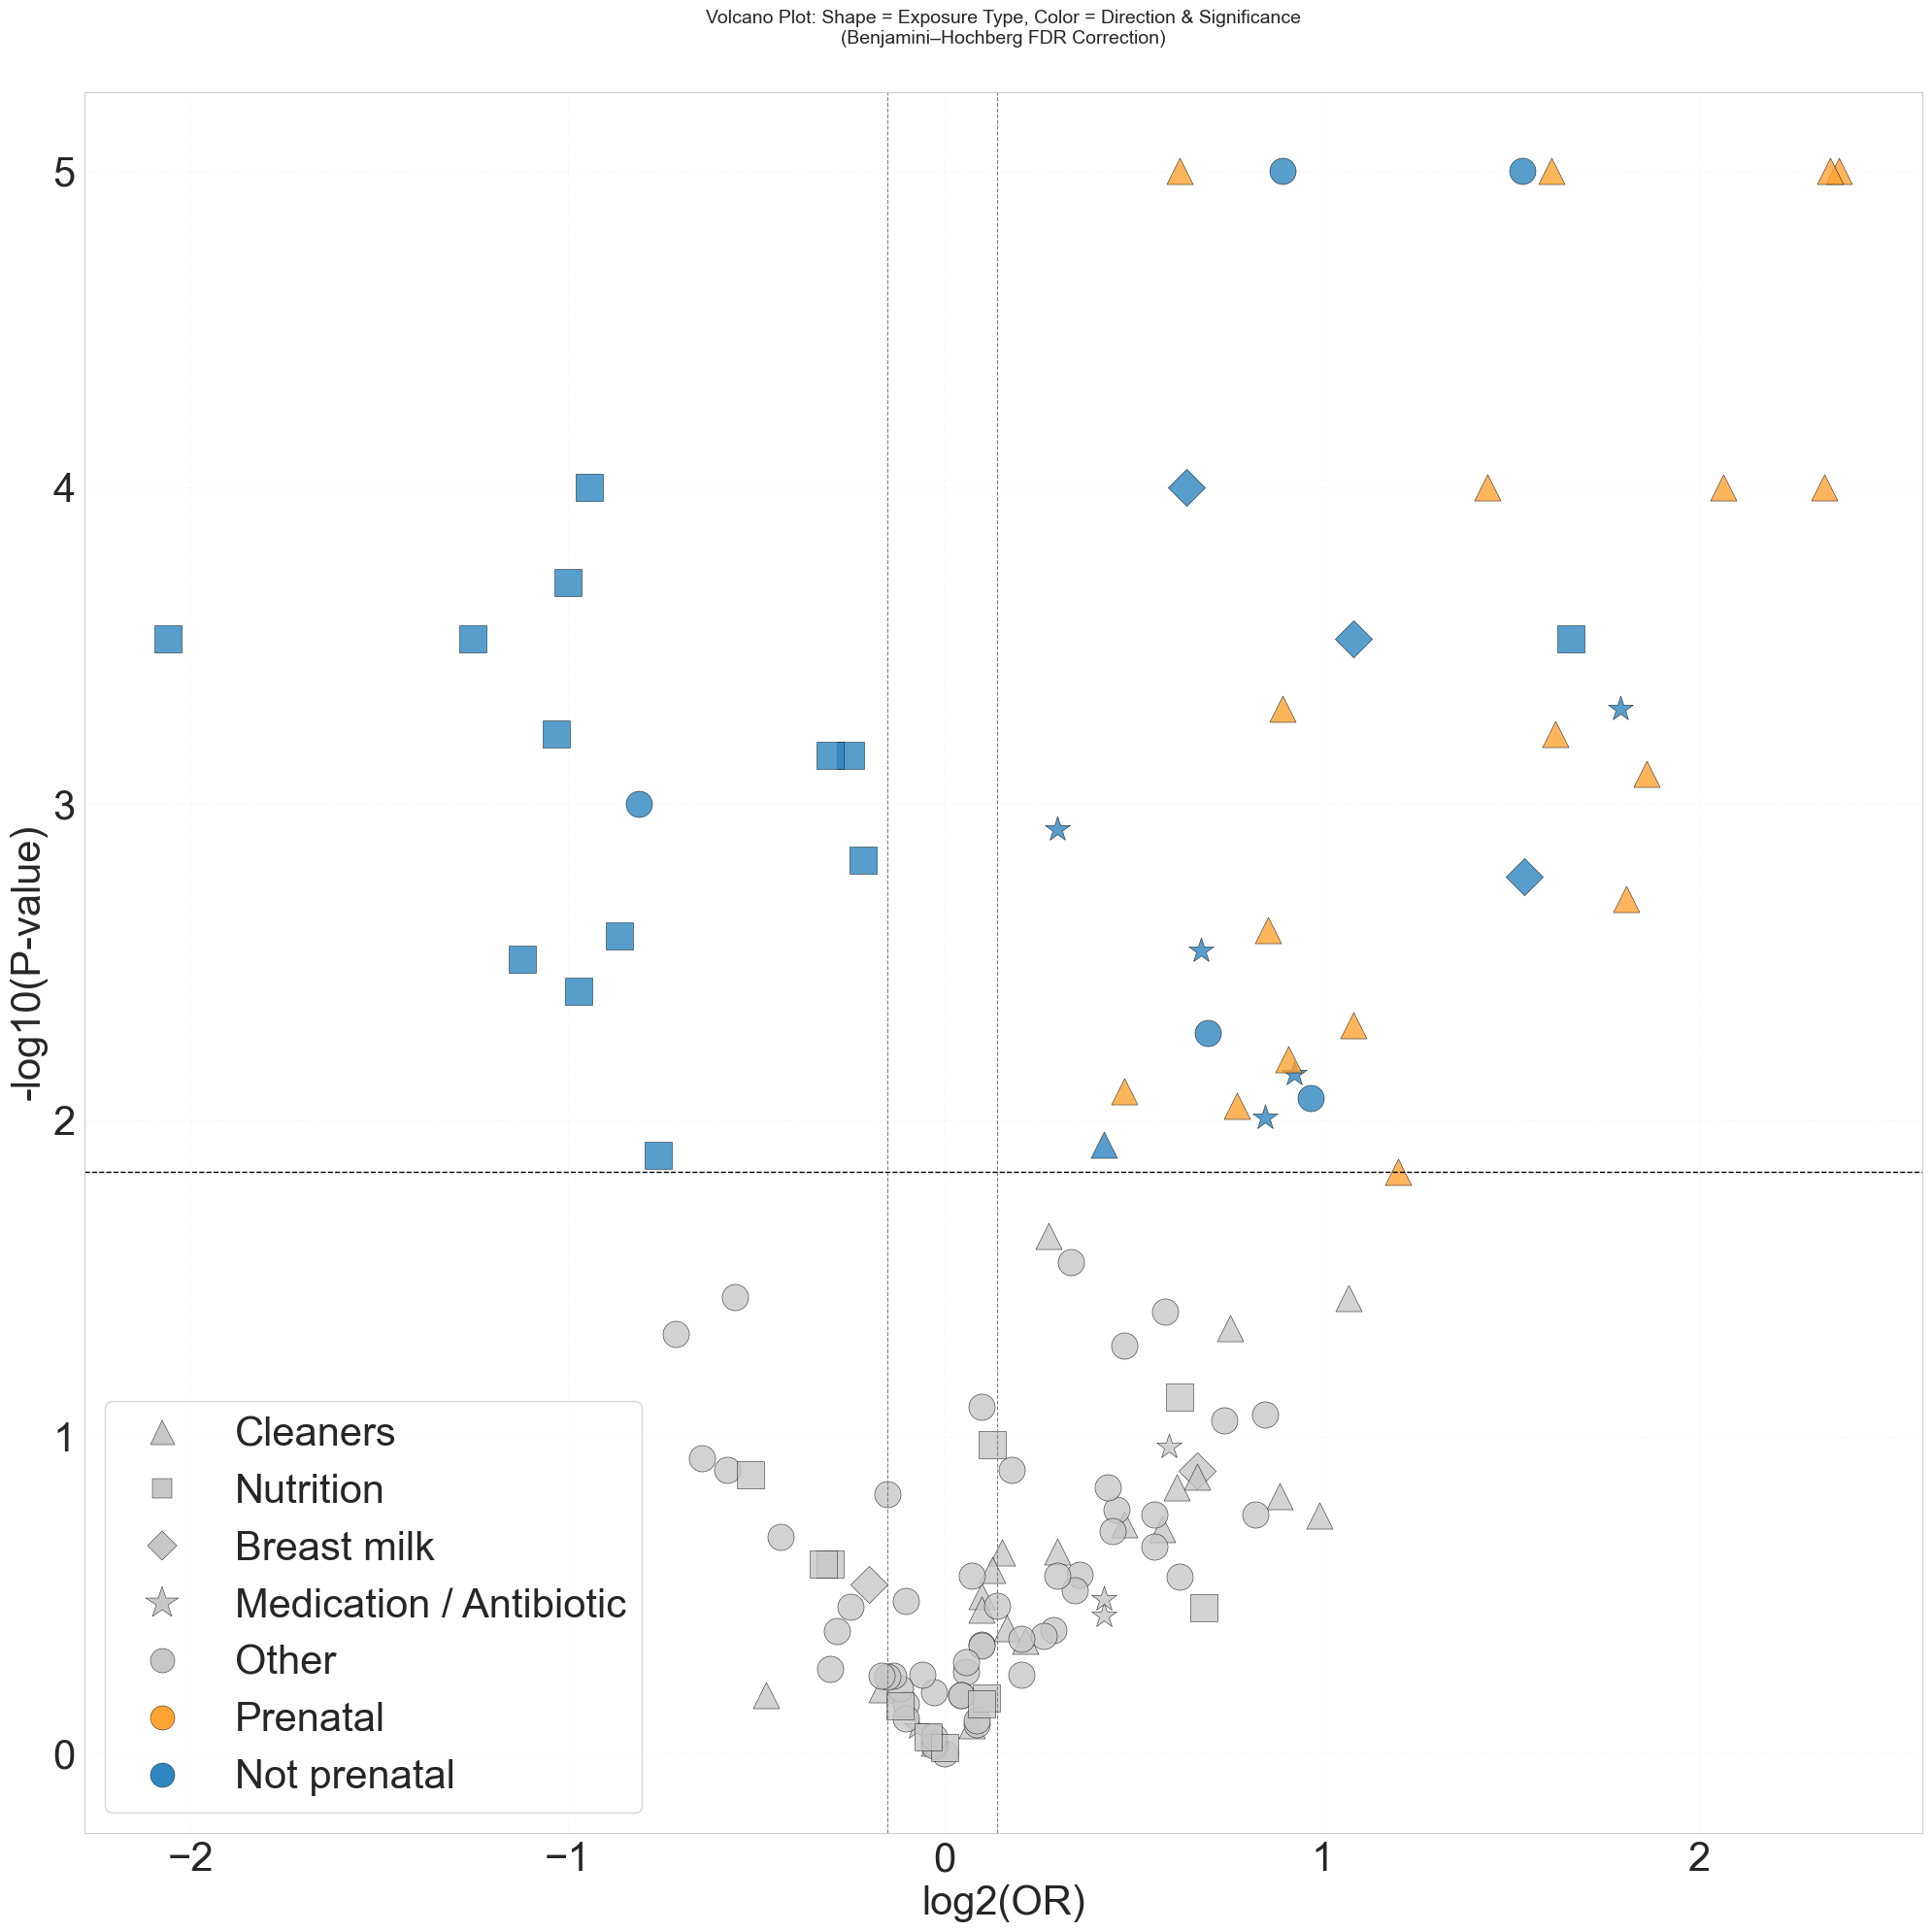

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D

# ------------- Load & Prep -------------
df = pd.read_csv("odds-ratios/round_2_exwas_asthma_5y.csv")

# Optional mapping (safe if exposure_to_name exists)
if 'exposure_to_name' in globals():
    df['exposure_name'] = df['exposure variable name'].map(exposure_to_name).fillna(df['exposure variable name'])
else:
    df['exposure_name'] = df['exposure variable name']

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Ensure numeric p-values
df['P-value'] = pd.to_numeric(df['P-value'], errors='coerce')

# Handle zero or very small p-values
min_nonzero = df.loc[df['P-value'] > 0, 'P-value'].min()
df.loc[df['P-value'] <= 0, 'P-value'] = min_nonzero / 10 if pd.notnull(min_nonzero) else 1e-300

# FDR correction (Benjamini–Hochberg)
reject, pvals_corrected, _, _ = multipletests(df['P-value'], alpha=0.05, method='fdr_bh')
df['FDR'] = pvals_corrected
df['Significant'] = reject

# Transforms
df['neg_log10_p'] = -np.log10(df['P-value'])
df['log2_OR']     = np.log2(df['OR'])

# Remove extreme ORs
df = df[df['OR'] <= 50]

# Keep only ORs outside 0.9–1.1
#df = df[(df['log2_OR'] >= np.log2(1.1)) | (df['log2_OR'] <= np.log2(0.9))]

# ------------- Shape & Color Rules -------------

# Defaults
df['marker'] = 'o'    # circle
df['color']  = '#C7C7C7' # gray (non-significant)

# Define masks using exposure_name
name_col = 'exposure_name'
cleaner_mask     = df[name_col].str.contains("Cleaners", case=False, na=False)
nutrition_mask   = df[name_col].str.contains("Nutrition", case=False, na=False)
breastmilk_mask  = df[name_col].str.contains("Breast milk", case=False, na=False)
medication_mask  = df[name_col].str.contains("Medication|antibiotic", case=False, na=False)
sig_mask         = df['Significant']

# Assign shapes
df.loc[cleaner_mask,    'marker'] = '^'  # up triangle
df.loc[nutrition_mask,  'marker'] = 's'  # square
df.loc[breastmilk_mask, 'marker'] = 'D'  # diamond
df.loc[medication_mask, 'marker'] = '*'  # star ⭐️

# Assign colors by significance and OR direction
# Set color based on whether 'prenatal' appears in the exposure name
df.loc[df['exposure'].str.contains('prenatal', case=False, na=False), 'color'] = "#FFA333"  # red
df.loc[~df['exposure'].str.contains('prenatal', case=False, na=False), 'color'] = '#2E86C1'  # blue
# Non-significant & prenatal remain red
# Non-significant & not prenatal remain blue
df.loc[~sig_mask, 'color'] = '#C7C7C7' # gray
# Non-significant remain gray

# ------------- Plot -------------
plt.figure(figsize=(20, 20))

# Vertical dashed lines
plt.axvline(x=np.log2(0.9), color='grey', linestyle='--', linewidth=0.8)
plt.axvline(x=np.log2(1.1), color='grey', linestyle='--', linewidth=0.8)

# FDR threshold line
fdr_threshold = 0.05
if any(df['FDR'] <= fdr_threshold):
    cutoff_y = -np.log10(df.loc[df['FDR'] <= fdr_threshold, 'P-value'].max())
    plt.axhline(y=cutoff_y, color='black', linestyle='--', linewidth=1, label='FDR = 0.05')

# Scatter each shape/color combo with larger markers
for (m, c), subset in df.groupby(['marker', 'color']):
    plt.scatter(
        subset['log2_OR'],
        subset['neg_log10_p'],
        marker=m,
        c=c,
        s=380,   # larger markers
        alpha=0.8,
        edgecolor='k',
        linewidth=0.4
    )

# --- Custom Legend ---
legend_elements = [
    Line2D([0],[0], marker='^', color='w', label='Cleaners',     markerfacecolor='#C7C7C7', markersize=18,markeredgecolor='k', markeredgewidth=0.3  ),
    Line2D([0],[0], marker='s', color='w', label='Nutrition',    markerfacecolor='#C7C7C7', markersize=15,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='D', color='w', label='Breast milk',  markerfacecolor='#C7C7C7', markersize=15,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='*', color='w', label='Medication / Antibiotic', markerfacecolor='#C7C7C7', markersize=25,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='o', color='w', label='Other',        markerfacecolor='#C7C7C7', markersize=18,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='o', color='w', label='Prenatal', markerfacecolor='#FFA333',  markersize=18,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='o', color='w', label='Not prenatal', markerfacecolor='#2E86C1', markersize=18,markeredgecolor='k', markeredgewidth=0.3),
]
plt.legend(handles=legend_elements, fontsize=30,loc='lower left' )

# --- Axes & Style ---
plt.xlabel('log2(OR)', fontsize=30)
plt.ylabel('-log10(P-value)', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.title('Volcano Plot: Shape = Exposure Type, Color = Direction & Significance\n(Benjamini–Hochberg FDR Correction)\n\n', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.1)
plt.tight_layout()

plt.savefig("volcano_fdr_shape_color_medication_star.png", dpi=300)
plt.show()


# Manuscript Figure 2b -   Volcano plot for asthma 8 year exwas

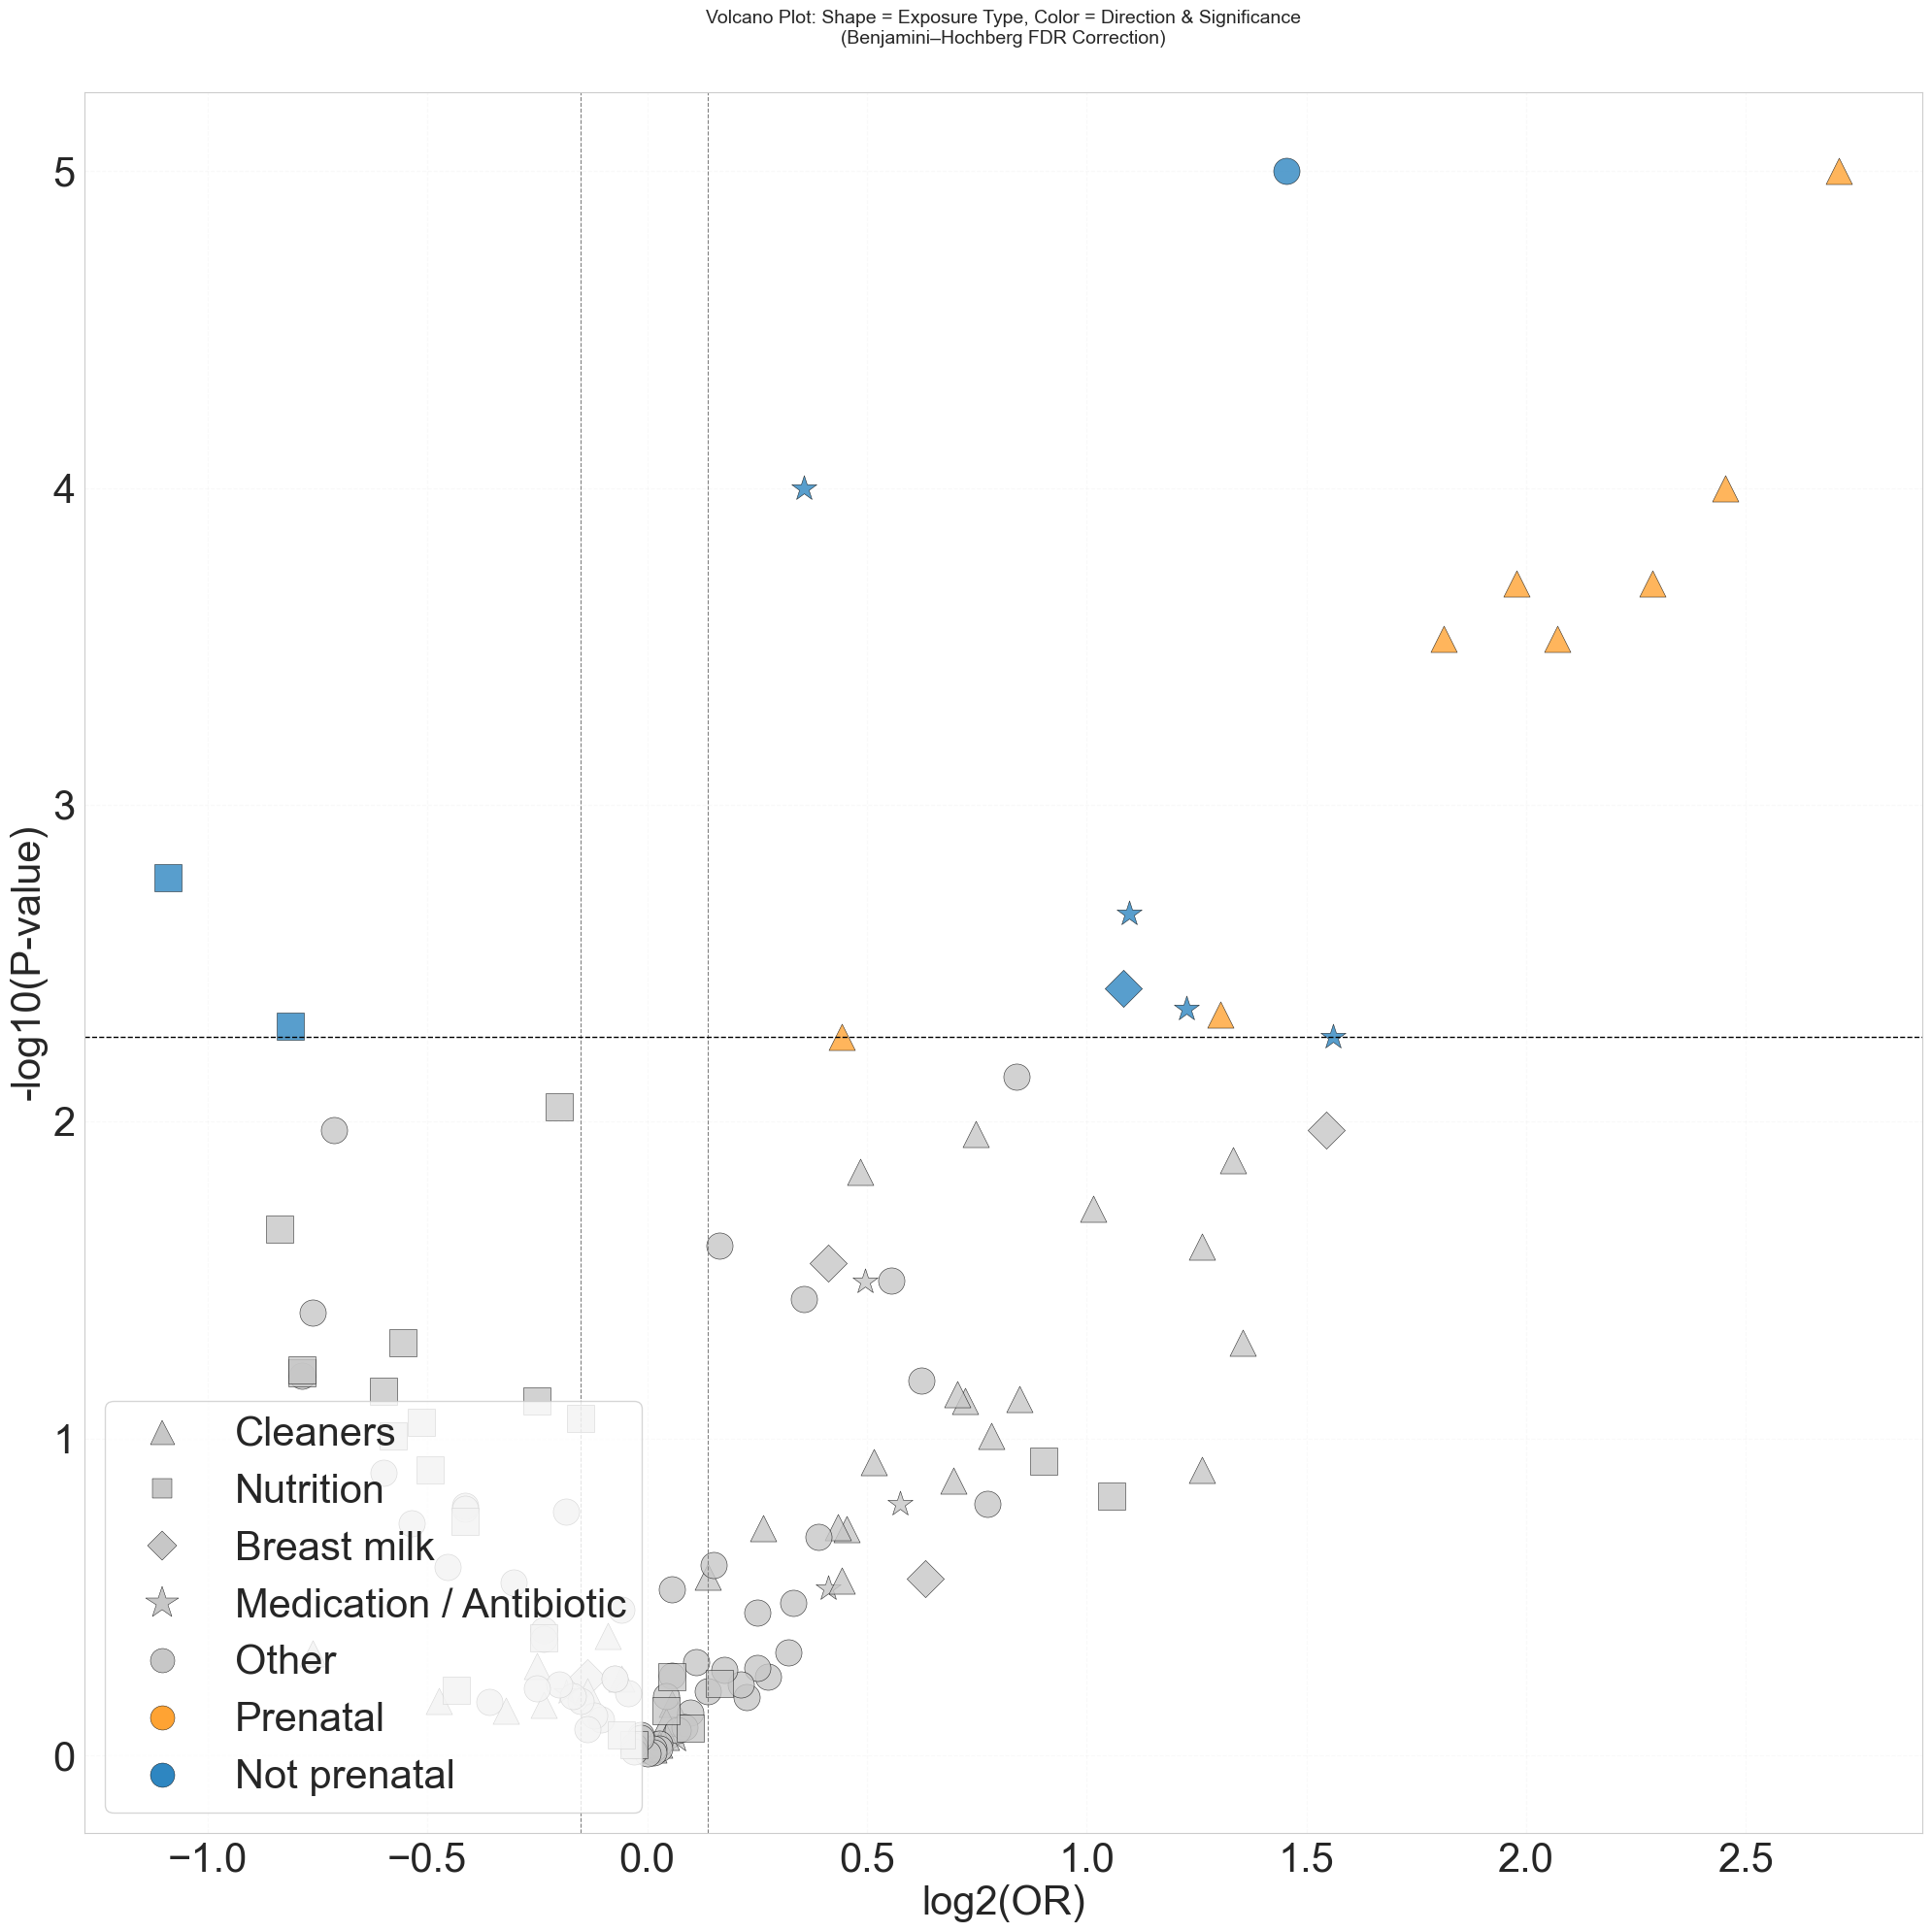

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D

# ------------- Load & Prep -------------
df = pd.read_csv("odds-ratios/round_2_exwas_asthma_8y.csv")

# Optional mapping (safe if exposure_to_name exists)
if 'exposure_to_name' in globals():
    df['exposure_name'] = df['exposure variable name'].map(exposure_to_name).fillna(df['exposure variable name'])
else:
    df['exposure_name'] = df['exposure variable name']

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Ensure numeric p-values
df['P-value'] = pd.to_numeric(df['P-value'], errors='coerce')

# Handle zero or very small p-values
min_nonzero = df.loc[df['P-value'] > 0, 'P-value'].min()
df.loc[df['P-value'] <= 0, 'P-value'] = min_nonzero / 10 if pd.notnull(min_nonzero) else 1e-300

# FDR correction (Benjamini–Hochberg)
reject, pvals_corrected, _, _ = multipletests(df['P-value'], alpha=0.05, method='fdr_bh')
df['FDR'] = pvals_corrected
df['Significant'] = reject

# Transforms
df['neg_log10_p'] = -np.log10(df['P-value'])
df['log2_OR']     = np.log2(df['OR'])

# Remove extreme ORs
df = df[df['OR'] <= 50]

# Keep only ORs outside 0.9–1.1
#df = df[(df['log2_OR'] >= np.log2(1.1)) | (df['log2_OR'] <= np.log2(0.9))]

# ------------- Shape & Color Rules -------------

# Defaults
df['marker'] = 'o'    # circle
df['color']  = '#C7C7C7' # gray (non-significant)

# Define masks using exposure_name
name_col = 'exposure_name'
cleaner_mask     = df[name_col].str.contains("Cleaners", case=False, na=False)
nutrition_mask   = df[name_col].str.contains("Nutrition", case=False, na=False)
breastmilk_mask  = df[name_col].str.contains("Breast milk", case=False, na=False)
medication_mask  = df[name_col].str.contains("Medication|antibiotic", case=False, na=False)
sig_mask         = df['Significant']

# Assign shapes
df.loc[cleaner_mask,    'marker'] = '^'  # up triangle
df.loc[nutrition_mask,  'marker'] = 's'  # square
df.loc[breastmilk_mask, 'marker'] = 'D'  # diamond
df.loc[medication_mask, 'marker'] = '*'  # star ⭐️

# Assign colors by significance and OR direction
# Set color based on whether 'prenatal' appears in the exposure name
df.loc[df['exposure'].str.contains('prenatal', case=False, na=False), 'color'] = '#FFA333'  # red
df.loc[~df['exposure'].str.contains('prenatal', case=False, na=False), 'color'] = '#2E86C1'  # blue
# Non-significant & prenatal remain red
# Non-significant & not prenatal remain blue
df.loc[~sig_mask, 'color'] = '#C7C7C7' # gray


# Non-significant remain gray

# ------------- Plot -------------
plt.figure(figsize=(20, 20))

# Vertical dashed lines
plt.axvline(x=np.log2(0.9), color='grey', linestyle='--', linewidth=0.8)
plt.axvline(x=np.log2(1.1), color='grey', linestyle='--', linewidth=0.8)

# FDR threshold line
fdr_threshold = 0.05
if any(df['FDR'] <= fdr_threshold):
    cutoff_y = -np.log10(df.loc[df['FDR'] <= fdr_threshold, 'P-value'].max())
    plt.axhline(y=cutoff_y, color='black', linestyle='--', linewidth=1, label='FDR = 0.05')

# Scatter each shape/color combo with larger markers
for (m, c), subset in df.groupby(['marker', 'color']):
    plt.scatter(
        subset['log2_OR'],
        subset['neg_log10_p'],
        marker=m,
        c=c,
        s=380,   # larger markers
        alpha=0.8,
        edgecolor='k',
        linewidth=0.4
    )

# --- Custom Legend ---
legend_elements = [
    Line2D([0],[0], marker='^', color='w', label='Cleaners',     markerfacecolor='#C7C7C7', markersize=18,markeredgecolor='k', markeredgewidth=0.3  ),
    Line2D([0],[0], marker='s', color='w', label='Nutrition',    markerfacecolor='#C7C7C7', markersize=15,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='D', color='w', label='Breast milk',  markerfacecolor='#C7C7C7', markersize=15,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='*', color='w', label='Medication / Antibiotic', markerfacecolor='#C7C7C7', markersize=25,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='o', color='w', label='Other',        markerfacecolor='#C7C7C7', markersize=18,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='o', color='w', label='Prenatal', markerfacecolor='#FFA333',  markersize=18,markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0],[0], marker='o', color='w', label='Not prenatal', markerfacecolor='#2E86C1', markersize=18,markeredgecolor='k', markeredgewidth=0.3),
]
plt.legend(handles=legend_elements, fontsize=30,loc='lower left' )

# --- Axes & Style ---
plt.xlabel('log2(OR)', fontsize=30)
plt.ylabel('-log10(P-value)', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.title('Volcano Plot: Shape = Exposure Type, Color = Direction & Significance\n(Benjamini–Hochberg FDR Correction)\n\n', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.1)
plt.tight_layout()

plt.savefig("volcano_fdr_shape_color_medication_star.png", dpi=300)
plt.show()


# Multiple testing correction of round 1 associations using Benjamini-Hochberg method

In [176]:
import statsmodels.stats.multitest
# Remove any nan p-values

frames = []
for outcome in outcomes:
    print(outcome)

    for visit in ['1 Year', '3 Years', '5 Years','8 Years']:
        
        temp = odds_ratio_table[(odds_ratio_table['outcome']==outcome) & (odds_ratio_table['time outcome assessed']==visit)]
        temp = temp[temp['P-value'].notna()]

        if len(temp)>0:
            

            outcome_year = ""
            if "1y" in outcome or "1Y" in outcome:
                outcome_year = "1 Year"
            if "3y" in outcome or "3Y" in outcome:
                outcome_year = "3 Years"
            if "5y" in outcome or "5Y" in outcome:
                outcome_year = "5 Years"
            if "8y" in outcome or "8Y" in outcome:
                outcome_year = "8 Years"
           
            if outcome_year == visit:


                # Perform multiple testing to get q value
                reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp['P-value'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
                # Adds the q-value (correct p-value) and Pass/Fail to the data frame
                temp['q']=q
                temp['reject_null']=reject
                #temp = temp[temp['reject_null']==True]
                
                temp.to_csv("odds-ratios/odds_ratios_round1_"+visit.replace(" ","_")+"_"+outcome+".csv",index=False)
                frames.append(temp.copy())

asthma_8y
asthma_possible_or_def_8Y
asthma_5y
asthma_possible_or_def_5Y
asthma_3y
asthma_possible_or_def_3Y
recurrent_wheeze_binary_1y
recurrent_wheeze_binary_3y
recurrent_wheeze_binary_5y


In [178]:
allframes = pd.concat(frames)
allframes.drop_duplicates(inplace=True)
allframes['exposure'] = allframes['exposure'].replace("asthma_diagnosed_by_doctor_PR18WK",'mother_asthma_diagnosed_by_doctor_PR18WK')
allframes.to_csv("manuscript/SUPPLEMENTARY-2026-March-17-ROUND1-all-results.csv",index=False)
allframes = allframes[allframes['q']<0.05]
allframes = allframes[allframes['total cases with exposure']>=10]
allframes = allframes[(allframes['OR']>1.1) | (allframes['OR']<0.9) ]
allframes.sort_values(by=['time outcome assessed','OR'],ascending = [True, False],inplace=True)
allframes.to_csv("manuscript/SUPPLEMENTARY-table-1-significant-exposures-by-timepoint-first-iteration-of-ExWAS.csv",index=False)
allframes.to_csv("manuscript/SUPPLEMENTARY-file-S1.csv",index=False)


In [181]:
len(allframes)

257

In [182]:
allframes2 = pd.read_csv("manuscript/SUPPLEMENTARY-table-1-significant-exposures-by-timepoint-first-iteration-of-ExWAS.csv")
allframes2 = pd.read_csv("manuscript/SUPPLEMENTARY-file-S1.csv")


# Determine number of unique exposures that are associated with one or more outcomes
We report those where q<0.05, total cases >=10, and Odds Ratio cutoff of >1.1 or <0.9

In [183]:
# Get a unique list of exposures that are significantly associated with at least one of the outcomes

round2_exposures_to_test = []
for index, row in allframes.iterrows():
    if row['exposure'] not in round2_exposures_to_test and row['q']<0.05 and row['total cases with exposure']>=10 and (row['OR']>1.1 or row['OR']<0.9):
        #print(row['exposure']+"\t"+str(row['OR'])+"\t"+row['outcome']+"\t"+str(row['total cases with exposure']))
        round2_exposures_to_test.append(row['exposure'])

print(len(round2_exposures_to_test))


126


In [184]:
num_exposures = len(allframes[(allframes['q']<0.05) & (allframes['total cases with exposure']>=10) & ((allframes['OR']<0.9) |  (allframes['OR']>1.1))]['exposure'].unique())
print(str(num_exposures)+ " exposures associated with at least one outcome")

126 exposures associated with at least one outcome


In [185]:
asthma_or_wheeze_related_exposures = []
# Get those exposures that are associated with asthma OR Recurrent wheeze
for index, row in allframes.iterrows():
    if row['exposure'] not in asthma_or_wheeze_related_exposures and row['q']<0.05 and row['total cases with exposure']>=10 and (row['OR']>1.1 or row['OR']<0.9):
        if row['outcome'] in ['asthma_8y','asthma_possible_or_def_8Y','asthma_5y','asthma_possible_or_def_5Y','asthma_3y','asthma_possible_or_def_3Y','recurrent_wheeze_binary_1y','recurrent_wheeze_binary_3y','recurrent_wheeze_binary_5y']:
            asthma_or_wheeze_related_exposures.append(row['exposure'])



In [186]:
print(str(len(asthma_or_wheeze_related_exposures)) + " exposures are associated with asthma and recurrent wheeze at least one time point")

126 exposures are associated with asthma and recurrent wheeze at least one time point


In [42]:
# Create a function to format the tick labels in figures with decimal notation
def log_fmt(x, pos):
    if x >= 1:
        return f"{x:.1f}"
    else:
        return f"{x:.1e}"

# ROUND 2 
## More stringent analysis using additional asthma-related confounders

In [242]:
subjects = pd.read_csv("data/aim2_exwas_data_2024-June-11.csv")

subjects.rename(columns={"asthma_diagnosed_by_doctor_PR18WK":'mother_asthma_diagnosed_by_doctor_PR18WK'},inplace=True)

In [ ]:
outcomes = ['asthma_8y','asthma_possible_or_def_8Y','asthma_5y','asthma_possible_or_def_5Y','asthma_3y','asthma_possible_or_def_3Y','recurrent_wheeze_binary_1y','recurrent_wheeze_binary_3y','recurrent_wheeze_binary_5y']

# This reads in user-friendly exposure names for figures to link to the abbreviated column names used in the analysis
exposure_to_name_df = pd.read_csv("../data/exposure_to_name.csv")
exposure_to_name = {}
for index, row in exposure_to_name_df.iterrows():
    exposure_to_name[row['Abbrev']]=row['Name']


outcome_to_name = {}
for outcome in outcomes:
    if outcome == "asthma_possible_or_def_8Y":
        outcome_to_name[outcome]='Asthma (definite and possible cases, clinician) at 8 years'

    if outcome == "asthma_possible_or_def_5Y":
        outcome_to_name[outcome]='Asthma (definite and possible cases, clinician) at 5 years'

    if outcome == "asthma_possible_or_def_3Y":
        outcome_to_name[outcome]='Asthma (definite and possible cases, clinician) at 3 years'

  
    
    if outcome =='asthma_3y':
        outcome_to_name[outcome]='Asthma (definite cases, clinician) at 3 years'

    if outcome == 'asthma_5y':
        outcome_to_name[outcome]='Asthma (definite cases, clinician) at 5 years'
    
    if outcome =='asthma_8y':
        outcome_to_name[outcome]='Asthma (definite cases, clinician) at 8 years'


    if outcome =='atopic_dermatitis_status_3y':
        outcome_to_name[outcome]='Atopic Dermatitis (3y)'
    
    if outcome == 'atopy_binary_3y':
        outcome_to_name[outcome] = 'Food or inhalant allergens (atopy) at 3y'
    if outcome == 'atopy_binary_5y':
        outcome_to_name[outcome] = 'Food or inhalant allergens (atopy) at 5y'
    
    if outcome == 'food_binary_3y':
        outcome_to_name[outcome] = 'Food allergy at 3y'

    if outcome =='atopic_dermatitis_status_1y':
        outcome_to_name[outcome]='Atopic Dermatitis (1y)'

    if outcome =='atopic_dermatitis_status_5y':
        outcome_to_name[outcome]='Atopic Dermatitis (5y)'
    
    if outcome == 'atopy_binary_1y':
        outcome_to_name[outcome] = 'Food or inhalant allergens (atopy) at 1y'
    
    if outcome == 'food_binary_1y':
        outcome_to_name[outcome] = 'Food allergy at 1y'
    if outcome == 'food_binary_3y':
        outcome_to_name[outcome] = 'Food allergy at 3y'
    if outcome == 'food_binary_5y':
        outcome_to_name[outcome] = 'Food allergy at 5y'

    if outcome == 'inhalant_binary_1y':
        outcome_to_name[outcome] = 'Inhalant allergy at 1y'
    if outcome == 'inhalant_binary_5y':
        outcome_to_name[outcome] = 'Inhalant allergy at 5y'
    if outcome == 'inhalant_binary_3y':
        outcome_to_name[outcome] = 'Inhalant allergy at 3y'

    if outcome == 'recurrent_wheeze_binary_1y':
        outcome_to_name[outcome] = 'Recurrent wheeze at 1y'
    if outcome == 'recurrent_wheeze_binary_3y':
        outcome_to_name[outcome] = 'Recurrent wheeze at 3y'
    if outcome == 'recurrent_wheeze_binary_5y':
        outcome_to_name[outcome] = 'Recurrent wheeze at 5y'       

    if outcome =='recurrent_wheeze_and_atopy_1y':
        outcome_to_name[outcome] = 'Recurrent wheeze and atopy at 1y'
    if outcome =='recurrent_wheeze_and_atopy_3y':
        outcome_to_name[outcome] = 'Recurrent wheeze and atopy at 3y'
    if outcome =='recurrent_wheeze_and_atopy_5y':
        outcome_to_name[outcome] = 'Recurrent wheeze and atopy at 5y'

covariates = ['family_asthma_history', 'num_antibiotic_courses_birth_to_1y', 'older_children_in_home_3m', 'total_household_income_PR18WK' , 'EBF_6m', 'vaginal_birth', 'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth','site_toronto', 'site_vancouver', 'site_edmonton','is_male','is_caucasian']

#exposures_and_covariates = round2_exposures_to_test +  covariates +['daily_hand_sanitizer_only_used_prenatal','weekly_or_more_bleach_only_used_prenatal','weekly_oven_or_degreaser_used_prenatal','daily_hand_sanitizer_or_general_disinfectant_used_prenatal','daily_general_disinfectant_used_prenatal','daily_hand_sanitizer_or_weekly_bleach']
exposures_and_covariates = round2_exposures_to_test +  covariates 

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','exposure variable name','covariate','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value','significant'])

                    
                
for outcome in outcomes:   
   
    print(outcome)

    for exposure in exposures_and_covariates:
       
       

        if exposure not in outcomes and exposure !='subject_id':     

                     

            adjusted_data_columns = []
            adjusted_data_columns.append(outcome)
            if exposure not in covariates:
                adjusted_data_columns.append(exposure)
            adjusted_data_columns = adjusted_data_columns + covariates
            adjusted_data_columns.append('subject_id')

            adjusted_data = subjects[adjusted_data_columns]
            adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]
            adjusted_data= adjusted_data[~adjusted_data[exposure].isna()]

            

            total_cases = adjusted_data[adjusted_data[outcome]==1]
            total_cases_exposed = total_cases[total_cases[exposure]!=0]
            y=adjusted_data[outcome]        

            adjusted_data.drop(columns=[outcome],inplace=True)
            adjusted_data = adjusted_data.fillna(adjusted_data.median())

    
            total_exposures = adjusted_data[adjusted_data[exposure]!=0]
            visit=""


            # Identify binary exposure varialbles and skip those for which there are not at least 30 children with each value

            number_unique = adjusted_data[exposure].nunique()
            if number_unique == 2:
                # Identify binary variables where at least one of the possible values occurs in less than 30 participants
                flag=0
                unique = adjusted_data[exposure].unique()
                for val in unique:
                    if len(adjusted_data[adjusted_data[exposure]==val])<30:
                        flag=1

            # Skip over associations with binary exposure variables that don't have at least 30 values for each possible value
            if (number_unique>2) or (number_unique==2 and flag==0):

                outcome_number = 0

                if "1y" in outcome or "1Y" in outcome:
                    visit="1 Year"
                    outcome_number = 1

    
                
                if "3y" in outcome or "3Y" in outcome:
                    visit="3 Years"
                    outcome_number = 3
                if "5y" in outcome or "5Y" in outcome:
                    visit="5 Years"
                    outcome_number = 5
                if "8y" in outcome or "8Y" in outcome:
                    visit="8 Years"
                    outcome_number = 8

                exposure_number = 0
                if "1y" in exposure or "1Y" in exposure:
                    exposure_number = 1

                if "18M" in exposure or "18m" in exposure:
                    exposure_number=1.5

                if "2y" in exposure or "2Y" in exposure:
                    exposure_number = 2

                if "30M" in exposure or "30m" in exposure:
                     exposure_number = 2.5

                if "3y" in exposure or "3Y" in exposure:
                    exposure_number = 3

                if "4y" in exposure or "4Y" in exposure:
                    exposure_number = 4

                if "5y" in exposure or "5Y" in exposure:

                    exposure_number = 5
                if "8y" in exposure or "8Y" in exposure:

                    exposure_number = 8

            # Remove these columns prior to building the model
                adjusted_data.drop(columns=['subject_id'],inplace=True)


                # Make sure predictor/exposure is not from a time point after the outcome
                if exposure_number <= outcome_number:
                    try:

                        X = sm.add_constant(adjusted_data) # add constant to allow intercept      

                        model = sm.Logit(y, X).fit(disp=0) # add disp=0 to turn off verbose output

                        odds_ratios = pd.DataFrame(
                            {
                                "OR": model.params,
                                "Lower CI": model.conf_int()[0],
                                "Upper CI": model.conf_int()[1]
                            }
                        )
                        odds_ratios = np.exp(odds_ratios)

                        odds_ratios['P-value'] = round(model.pvalues,4)
                        odds_ratios[odds_ratios['P-value']<0.05]

                        odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                        odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                        odds_ratios['OR'] = round(odds_ratios['OR'],2)

                        odds_ratios = odds_ratios.loc[exposure]    
                        significant_effect_row = odds_ratios.to_dict()
                        if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                        elif significant_effect_row['P-value']<0.01:
                            significant_effect_row['significant']="**"
                        else:
                            significant_effect_row['significant']=""

                        significant_effect_row['outcome']= outcome_to_name[outcome]
                        if exposure in covariates:
                            significant_effect_row['covariate']="Yes"
                        else:
                            significant_effect_row['covariate']=""

                        significant_effect_row['exposure variable name']=exposure
                        if exposure in exposure_to_name:
                            significant_effect_row['exposure']=exposure_to_name[exposure]
                        else:
                            significant_effect_row['exposure']=exposure                         
                            
                        significant_effect_row['time outcome assessed']=visit
                        significant_effect_row['total cases']=len(total_cases)
                        significant_effect_row['total exposures']=len(total_exposures)
                        significant_effect_row['total cases with exposure']=len(total_cases_exposed)

                        significant_effect_row['total children']=len(adjusted_data)
                        odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row
                    except:
                        print("Error with outcome: "+outcome+", exposure: "+exposure)
        
   

odds_ratio_table.drop_duplicates(inplace=True)

# Takes approximately 30s to run on MacBook Pro with M1 chip

asthma_8y
asthma_possible_or_def_8Y
asthma_5y
asthma_possible_or_def_5Y
asthma_3y
asthma_possible_or_def_3Y
recurrent_wheeze_binary_1y
recurrent_wheeze_binary_3y
recurrent_wheeze_binary_5y


In [272]:
odds_ratio_table.to_csv("odds-ratios/odds_ratios-round2-raw.csv",index=False)

In [273]:
len(odds_ratio_table)

1190

In [274]:
odds_ratio_table = pd.read_csv("odds-ratios/odds_ratios-round2-raw.csv")

# Multiple testing correction for second round of logistic regression using more outcomes and controls

In [275]:
import statsmodels.stats.multitest
# Remove any nan p-values

frames = []
    
for outcome in outcomes:


    for visit in ['1 Year', '3 Years', '5 Years','8 Years']:

        outcome_year = ""
        if "1y" in outcome or "1Y" in outcome:
            outcome_year = "1 Year"
        if "3y" in outcome or "3Y" in outcome:
            outcome_year = "3 Years"
        if "5y" in outcome or "5Y" in outcome:
            outcome_year = "5 Years"
        if "8y" in outcome or "8Y" in outcome:
            outcome_year = "8 Years"
        
        if outcome_year == visit:

            temp = odds_ratio_table[(odds_ratio_table['outcome']==outcome_to_name[outcome]) & (odds_ratio_table['time outcome assessed']==visit)]
            temp = temp[temp['P-value'].notna()]
            
            if len(temp)>0:


                #if (visit == ' 1 Year' and "1y" in outcome) or (visit == ' 3 Years' and "3y" in outcome) or (visit == ' 5 Years' and "5y" in outcome) or (visit == ' 8 Years' and "8y" in outcome):

                # Perform multiple testing to get q value
                reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp['P-value'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
                # Adds the q-value (correct p-value) and Pass/Fail to the data frame
                temp['q']=q
                temp['reject_null']=reject

                frames.append(temp.copy())

              
                temp.to_csv("odds-ratios/round2_significant_exposures_"+visit.replace(" ","_")+"_"+outcome+".csv",index=False)


### Send all significant exposures to a file

In [258]:
allframes = pd.concat(frames)
allfames_including_insignificant = allframes.copy()
#allframes = allframes[(allframes['q']<0.05) & (allframes['total cases with exposure']>=10) & ((allframes['OR']<0.9) |  (allframes['OR']>1.1))]

allframes.sort_values(by=['time outcome assessed','OR'],ascending = [True, False],inplace=True)
allframes.to_csv("manuscript/SUPPLEMENTARY-table-2-significant-exposures-by-timepoint-second-iteration-of-ExWAS.csv",index=False)
allframes.to_csv("manuscript/SUPPLEMENTARY-file-S2",index=False)

# Calculate number of unique exposures associated with at least one outcome after adjusting for additional confounders

In [259]:
print(str(len(allframes['exposure'].unique()))+ " unique exposures with significant associations to at least one outcome including asthma and wheeze")

136 unique exposures with significant associations to at least one outcome including asthma and wheeze


In [251]:
asthma_or_wheeze_related_exposures = []
# Get those exposures that are associated with asthma OR Recurrent wheeze
for index, row in allframes.iterrows():
    if row['exposure'] not in asthma_or_wheeze_related_exposures and row['q']<0.05 and row['total cases with exposure']>=10 and (row['OR']>1.1 or row['OR']<0.9):
        if row['outcome'] in ['Asthma (definite cases, clinician) at 8 years','Asthma (definite and possible cases, clinician) at 3 years','Asthma (definite cases, clinician) at 5 years','Asthma (definite and possible cases, clinician) at 5 years','Asthma (definite cases, clinician) at 3 years','Asthma (definite and possible cases, clinician) at 3 years','Recurrent wheeze at 1y','Recurrent wheeze at 3y','Recurrent wheeze at 5y']:
            asthma_or_wheeze_related_exposures.append(row['exposure'])


In [239]:
print(str(len(asthma_or_wheeze_related_exposures))+ " unique exposures with significant associations to at least one outcome including asthma, wheeze")

112 unique exposures with significant associations to at least one outcome including asthma, wheeze


### Create a table summarizing number of significant exposures associated with each outcome

In [240]:
outcome_df2 = outcome_df.copy()
outcome_df2.drop(columns=['Cases'],inplace=True)
for index,row in outcome_df2.iterrows():
    positive_associations_df = allframes[(allframes['outcome']==outcome_to_name[index]) & (allframes['OR']>1)]
    outcome_df2.loc[index,"Positively associated"]=len(positive_associations_df)

    negative_associations_df = allframes[(allframes['outcome']==outcome_to_name[index]) & (allframes['OR']<1)]
    outcome_df2.loc[index,"Negatively associated"]=len(negative_associations_df)

outcome_df2['Negatively associated'] = outcome_df2['Negatively associated'] .astype(int)
outcome_df2['Positively associated'] = outcome_df2['Positively associated'] .astype(int)

In [201]:
outcome_df2

,Visit,Outcome,Positively associated,Negatively associated
asthma_8y,8 years,"Asthma (definite cases, clinician)",77,56
asthma_possible_or_def_8Y,8 years,"Asthma (definite and possible cases, clinician)",71,60
asthma_5y,5 years,"Asthma (definite cases, clinician)",88,44
asthma_possible_or_def_5Y,5 years,"Asthma (definite and possible cases, clinician)",89,41
asthma_3y,3 years,"Asthma (definite cases, clinician)",98,31
asthma_possible_or_def_3Y,3 years,"Asthma (definite and possible cases, clinician)",97,34
recurrent_wheeze_binary_1y,1 year,Recurrent wheeze,97,21
recurrent_wheeze_binary_3y,3 years,Recurrent wheeze,101,31
recurrent_wheeze_binary_5y,5 years,Recurrent wheeze,80,54


In [202]:
pivot_table_frames = pd.pivot_table(outcome_df2, index=["Outcome"], columns=["Visit"], values=['Negatively associated','Positively associated'])
pivot_table_frames.replace(np.nan,"",inplace=True)
pivot_table_frames.to_excel("manuscript/round2-table-summary-pos-vs-neg-associations.xlsx")

# Summary of exposures that were negatively or positively associated with each of the outcomes
Originally planned to include this as a table in the manuscript, however, for brevity we decided to allude to numbers based on contents of SUPPLEMENTARY-file-S2.

In [205]:
pivot_table_frames

Negatively associated          \
Visit                                                          1 year 3 years   
Outcome                                                                         
Asthma (definite and possible cases, clinician)                          34.0   
Asthma (definite cases, clinician)                                       31.0   
Recurrent wheeze                                                 21.0    31.0   

                                                                 \
Visit                                           5 years 8 years   
Outcome                                                           
Asthma (definite and possible cases, clinician)    41.0    60.0   
Asthma (definite cases, clinician)                 44.0    56.0   
Recurrent wheeze                                   54.0           

                                                Positively associated          \
Visit                                                          1 year 3 years   
Outcome                                                                         
Asthma (definite and possible cases, clinician)                          97.0   
Asthma (definite cases, clinician)                                       98.0   
Recurrent wheeze                                                 97.0   101.0   

                                                                 
Visit                                           5 years 8 years  
Outcome                                                          
Asthma (definite and possible cases, clinician)    89.0    71.0  
Asthma (definite cases, clinician)                 88.0    77.0  
Recurrent wheeze                                   80.0

### Determine the number of unique exposures associated with at least one of the outcomes used in the round 2 ExWAS
- Odds ratio >=1.1 or <=0.9 and not a covariate

In [204]:
num_exposures = len(allframes[(allframes['q']<0.05) & (allframes['covariate']!='Yes') & (allframes['total cases with exposure']>=10)  & ((allframes['OR']<0.9) |  (allframes['OR']>1.1))]['exposure'].unique())
print(str(num_exposures)+ " exposures associated with at least one outcome after excluding additional asthma confounders in the count")

103 exposures associated with at least one outcome after excluding additional asthma confounders in the count


# FOREST PLOTS

# Manuscript Figure 2d - Definite asthma at 8 years (all significant exposures)

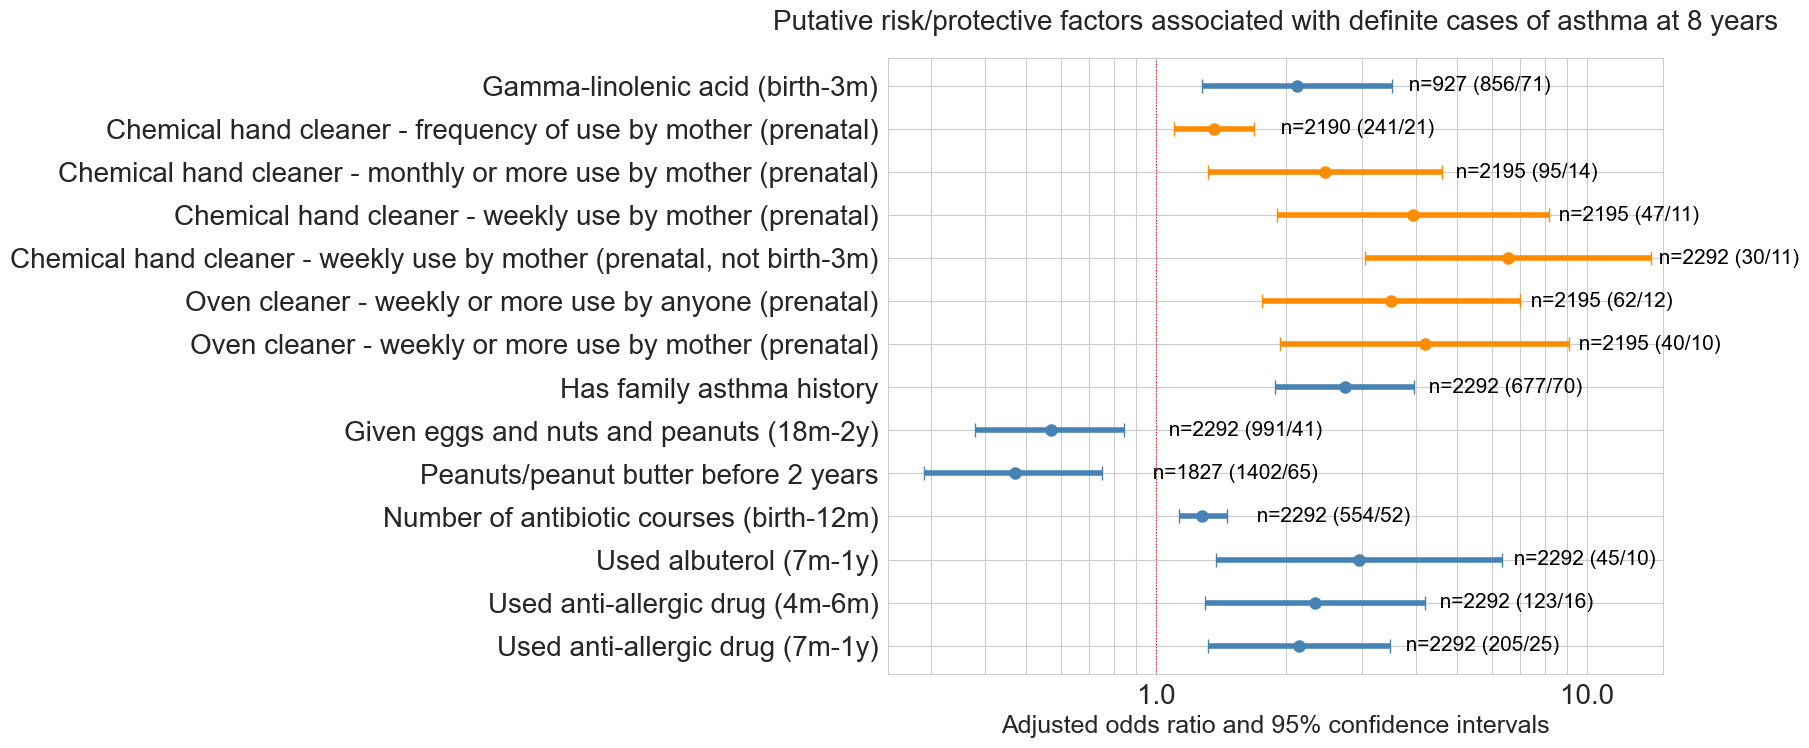

In [49]:
odds_ratio_table = pd.read_csv("odds-ratios/round2_significant_exposures_8_Years_asthma_8y.csv")
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")


sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(10, 8))
plt.title("Putative risk/protective factors associated with definite cases of asthma at 8 years",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():



    row['exposure'] = row['exposure'].replace("Vitamins or supplements - ","").capitalize()
    row['exposure'] = row['exposure'].replace("Breast milk - ","").capitalize()
    row['exposure'] = row['exposure'].replace("Food products - ","").capitalize()
    row['exposure'] = row['exposure'].replace("Cleaners - ","").capitalize()
    row['exposure'] = row['exposure'].replace("Dehp phthalate exposure - ","").capitalize()
    row['exposure'] = row['exposure'].replace("Medications - ","").capitalize()
    row['exposure'] = row['exposure'].replace("Covariate - ","").capitalize()
    row['exposure'] = row['exposure'].replace(" (all-cis-docosa-7,10,13,16-tetraenoic acid)","").capitalize()
    row['exposure'] = row['exposure'].replace(" (vitamins a, c, d, b1, b2, b3, b6)","").capitalize()
    row['exposure'] = row['exposure'].replace("dehp","DEHP")
    row['exposure'] = row['exposure'].replace("(prenatal, not 6m-12m","(prenatal, not 6m-12m)")
    if row['time outcome assessed']=='8 Years' and row['total cases with exposure']>=10:
        ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
        if row['q'] < 0.05 and (row['OR']>1.1 or row['OR']<0.9) and row['OR']<100:
            label = str(row['OR'])
            if "prenatal" in row['exposure']:
                plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='darkorange', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="darkorange", mec="darkorange")
            else:
                plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='steelblue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="steelblue", mec="steelblue")
       

            label = ' n='+str(row['total children']) + " ("+ str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])+')'
            # Add text to the right of the error bar
            plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=15)



plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')
        
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=18)

plt.xlim(0,15)

plt.savefig('figures/round2_all_exposures_definite_asthma_8y.png')
plt.show()

# Manuscript Figure 2b - Forest plot for definite asthma at 5 years

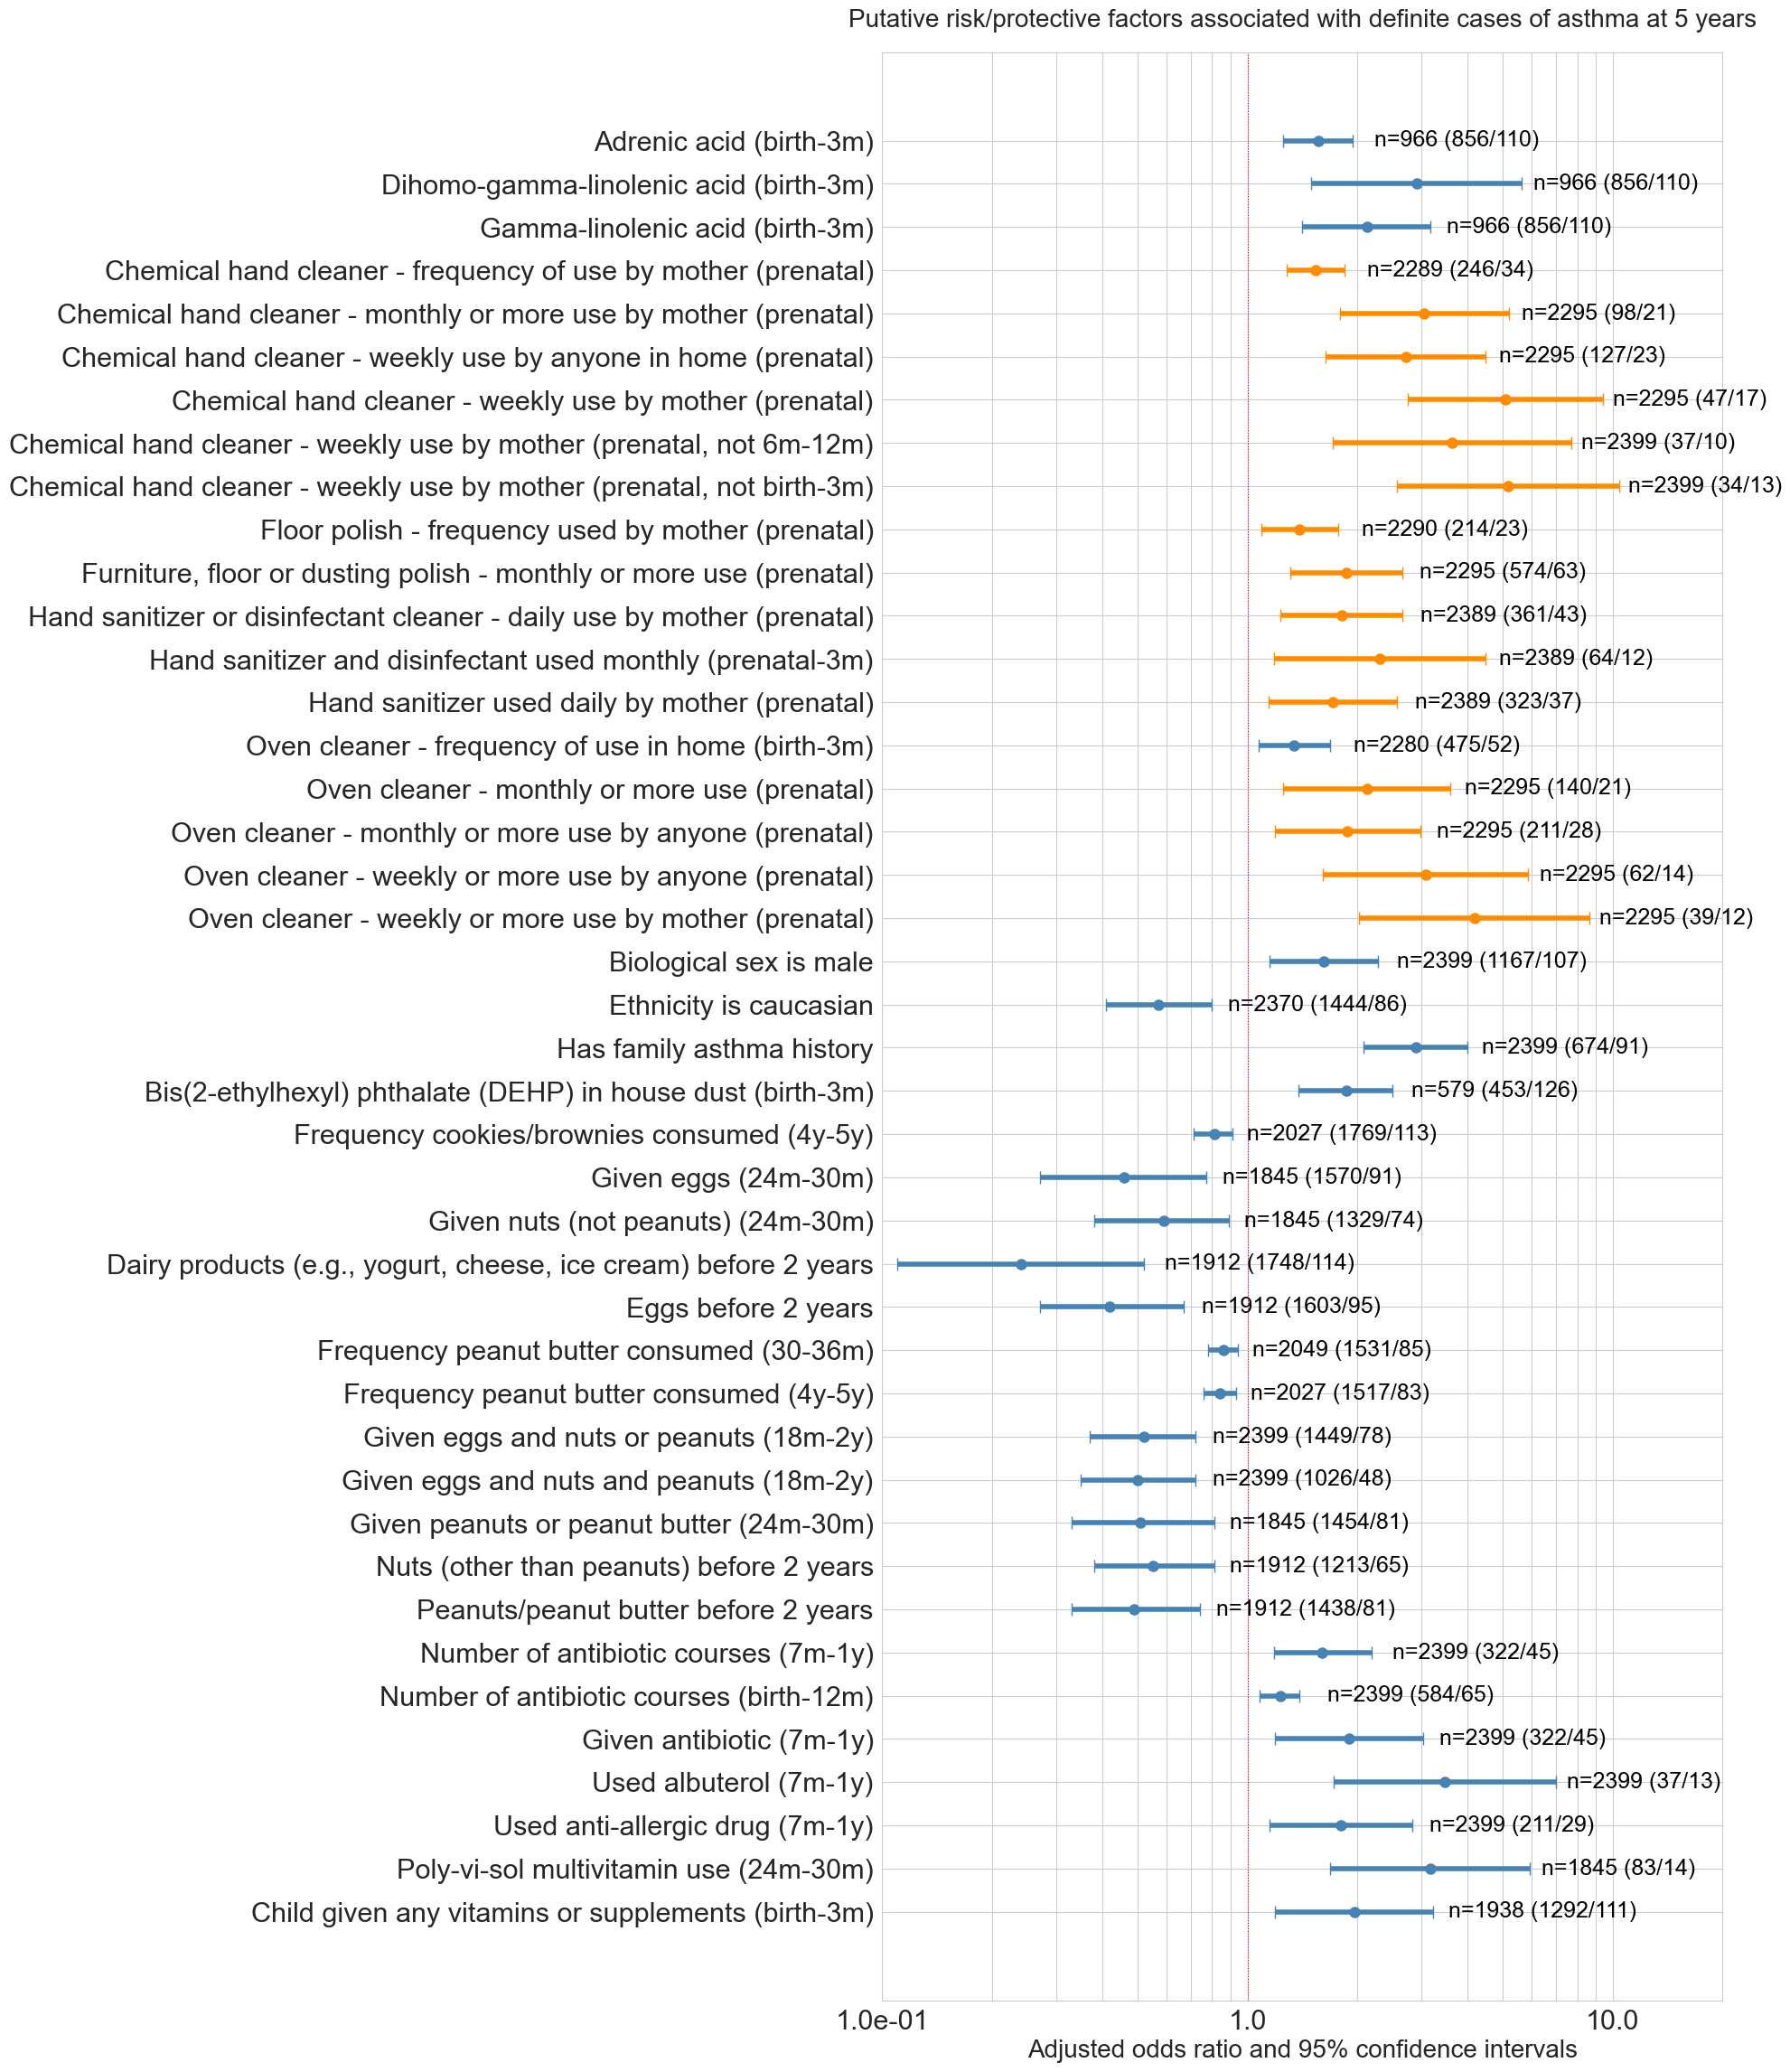

In [54]:
odds_ratio_table = pd.read_csv("odds-ratios/round2_significant_exposures_5_Years_asthma_5y.csv")
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(12, 28))
plt.title("Putative risk/protective factors associated with definite cases of asthma at 5 years",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():


        row['exposure'] = row['exposure'].replace("Vitamins or supplements - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Breast milk - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Food products - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Cleaners - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Dehp phthalate exposure - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Medications - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Covariate - ","").capitalize()
        row['exposure'] = row['exposure'].replace(" (all-cis-docosa-7,10,13,16-tetraenoic acid)","").capitalize()
        row['exposure'] = row['exposure'].replace(" (vitamins a, c, d, b1, b2, b3, b6)","").capitalize()
        row['exposure'] = row['exposure'].replace("dehp","DEHP")
        row['exposure'] = row['exposure'].replace("(prenatal, not 6m-12m","(prenatal, not 6m-12m)")


        if row['time outcome assessed']=='5 Years' and row['total cases with exposure']>=10:
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if row['q'] < 0.05 and (row['OR']>1.1 or row['OR']<0.9) and row['OR']<10:
                label = str(row['OR'])
                if "prenatal" in row['exposure']:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='darkorange', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="darkorange", mec="darkorange")
                else:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='steelblue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="steelblue", mec="steelblue")
            #else:
            #    label = str(row['OR'])
            #    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:grey', capsize=5, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:grey", mec="tab:grey")

                label = ' n='+str(row['total children']) + " ("+ str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])+')'
            # Add text to the right of the error bar
                if row['OR']>1.1:
                    plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=18)
                else:
                    plt.text(row['OR'] + ci[1][0] + 0.05, row['exposure'], f'{label}', color='black', va='center', fontsize=18)



#plt.xscale('log')
plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')



plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=22)


plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=20)

plt.xlim(0.1,20)


plt.show()

In [ ]:
exposure_to_name = {

    'pita_bread_5Y':'Child nutrition - frequency pita bread consumed (4y-5y)',
    'NHPMD_proximity_childcare_facility_18WK_above_90_percentile':'Built environment - distance to childcare faciltiy above 90th percentile (prenatal)',
    'WTH_annual_avg_length_cool_events_based_on_min_temp_18WK_above_90_percentile':'Climate - Annual average length of cool events based on minimum temperature in upper 90th percentile (prenatal)',
    'WTH_annual_avg_snow_per_event_18WK_below_10_percentile':'Climate - Annual average amount of snow per event below 10th percentile (prenatal)',
    'WTH_annual_num_days_with_rain_18WK_above_90_percentile':'Climate - Annual number of days with rain above 90th percentile (prenatal)',
    'food_solid_shellfish_30m':'Child nutrition - given shellfish (2y-30m)',
    'landsat_gmn_mean_grow_season_mean_ndvi_100m_5Y':'Greenness - Mean of growing season mean NDVI within 100m is above 90th percentile (5 years)',
    'landsat_gp_mean_of_max_ann_ndvi_100m_5Y':'Mean of maximum annual NDVI within 100m is above 90th percentile (5 years)',
    'poly_vi_sol_with_or_without_iron_30m':'Child nutrition - Poly-Vi-Sol (Vitamins A, C, D, B1, B2, B3, B6) with/without iron multivitamin use (24m-30m)',
    'weekly_chem_hand_cleaner_or_sanitizer_by_mother_prenatal': 'Cleaners - chemical hand cleaner or hand sanitizer - weekly use by mother (prenatal)',
    '':'',
}

In [ ]:
exposure_to_name = {

    'pita_bread_5Y':'Child nutrition - frequency pita bread consumed (4y-5y)',
    'NHPMD_proximity_childcare_facility_18WK_above_90_percentile':'Built environment - distance to childcare faciltiy above 90th percentile (prenatal)',
    'WTH_annual_avg_length_cool_events_based_on_min_temp_18WK_above_90_percentile':'Climate - Annual average length of cool events based on minimum temperature in upper 90th percentile (prenatal)',
    'WTH_annual_avg_snow_per_event_18WK_below_10_percentile':'Climate - Annual average amount of snow per event below 10th percentile (prenatal)',
    'WTH_annual_num_days_with_rain_18WK_above_90_percentile':'Climate - Annual number of days with rain above 90th percentile (prenatal)',
    'food_solid_shellfish_30m':'Child nutrition - given shellfish (2y-30m)',
    'landsat_gmn_mean_grow_season_mean_ndvi_100m_5Y':'Greenness - Mean of growing season mean NDVI within 100m is above 90th percentile (5 years)',
    'landsat_gp_mean_of_max_ann_ndvi_100m_5Y':'Mean of maximum annual NDVI within 100m is above 90th percentile (5 years)',
    'poly_vi_sol_with_or_without_iron_30m':'Child nutrition - Poly-Vi-Sol (Vitamins A, C, D, B1, B2, B3, B6) with/without iron multivitamin use (24m-30m)',
    'weekly_chem_hand_cleaner_or_sanitizer_by_mother_prenatal': 'Cleaners - chemical hand cleaner or hand sanitizer - weekly use by mother (prenatal)',
    'frequency_of_use_of_oven_cleaner_5Y':'Cleaners - oven cleaner - frequency of use in home (4y-5y)',
    'food_age_infant_cereals_6m':'Child nutrition - given infant cereal (6 months)',
    'NHGRD_avg_500m_5Y':'Greenness - Average greenness along urban roads within 500m is above 90th percentile (5 years)'
}

# Manuscript Supplementary Figure 3 - Definite asthma at 3 years (all significant exposures)

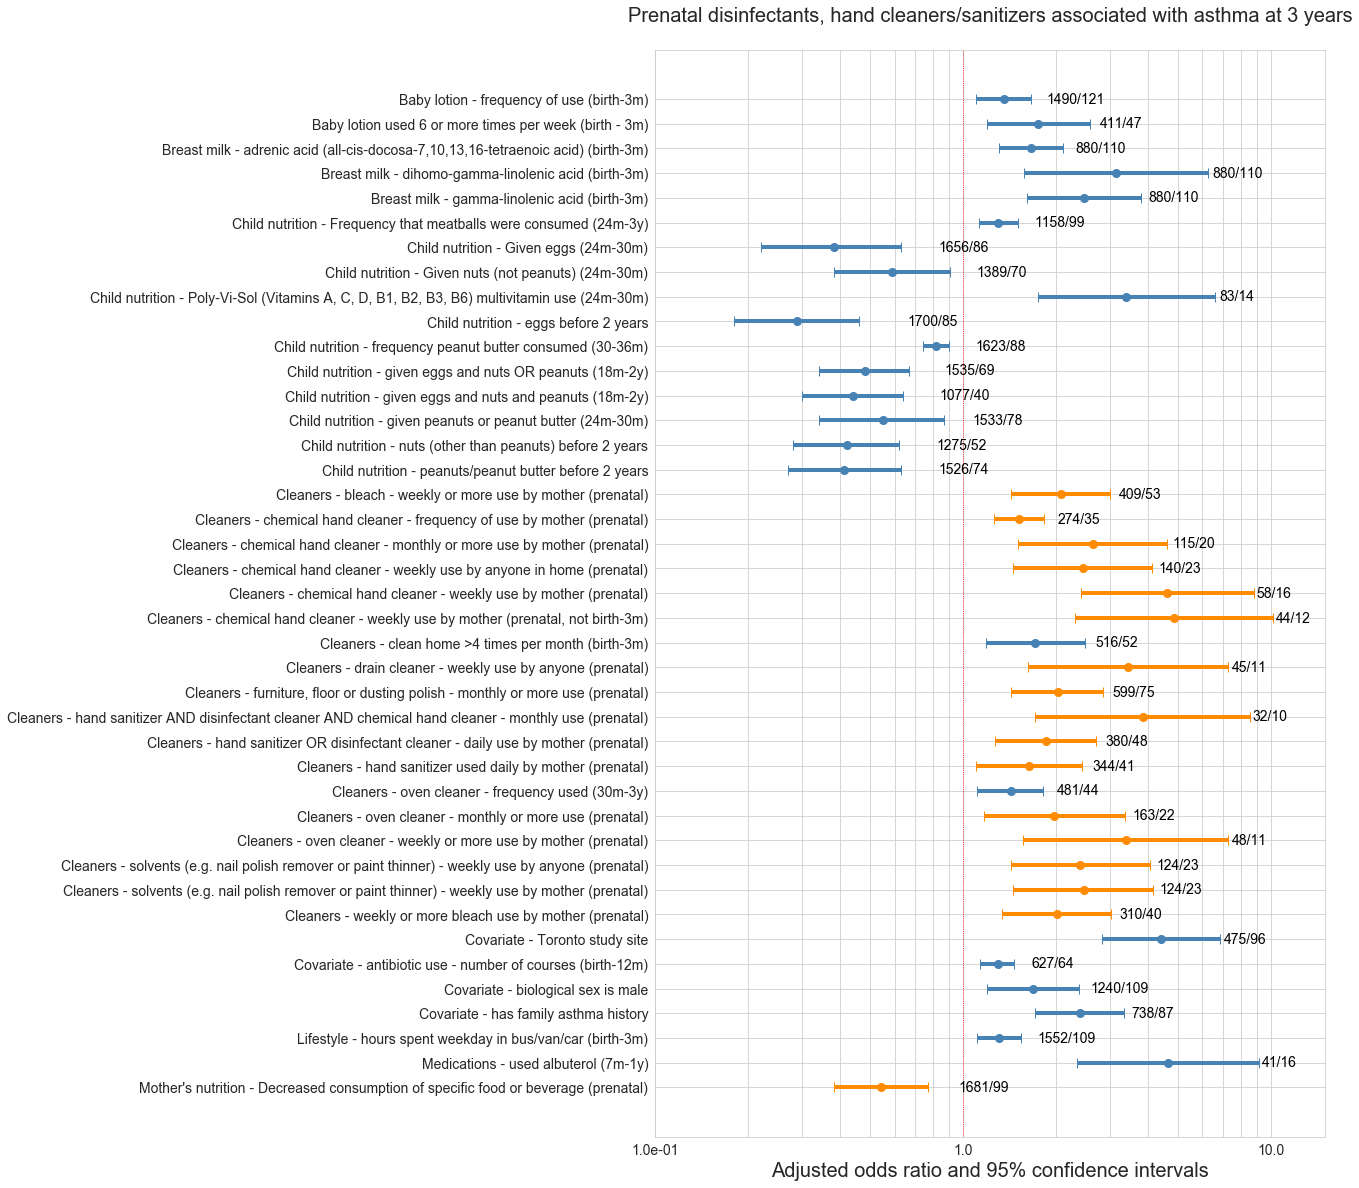

In [ ]:
odds_ratio_table = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_asthma_3y.csv")
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(12, 20))
plt.title("Prenatal disinfectants, hand cleaners/sanitizers associated with asthma at 3 years\n",fontsize=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
    if row['time outcome assessed']=='3 Years' and row['total cases with exposure']>=10:
        ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
        if row['q'] < 0.05 and (row['OR']>1.0 or row['OR']<0.9) and row['OR']<10:
            label = str(row['OR'])
            if "prenatal" in row['exposure']:
                plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='darkorange', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="darkorange", mec="darkorange")
            else:
                plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='steelblue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="steelblue", mec="steelblue")
            label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])
            # Add text to the right of the error bar
            plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=14)

plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')

plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=20)

plt.xlim(0.1,15)
plt.savefig('figures/round2_all_significant_variables_asthma_3y.png')
plt.show()

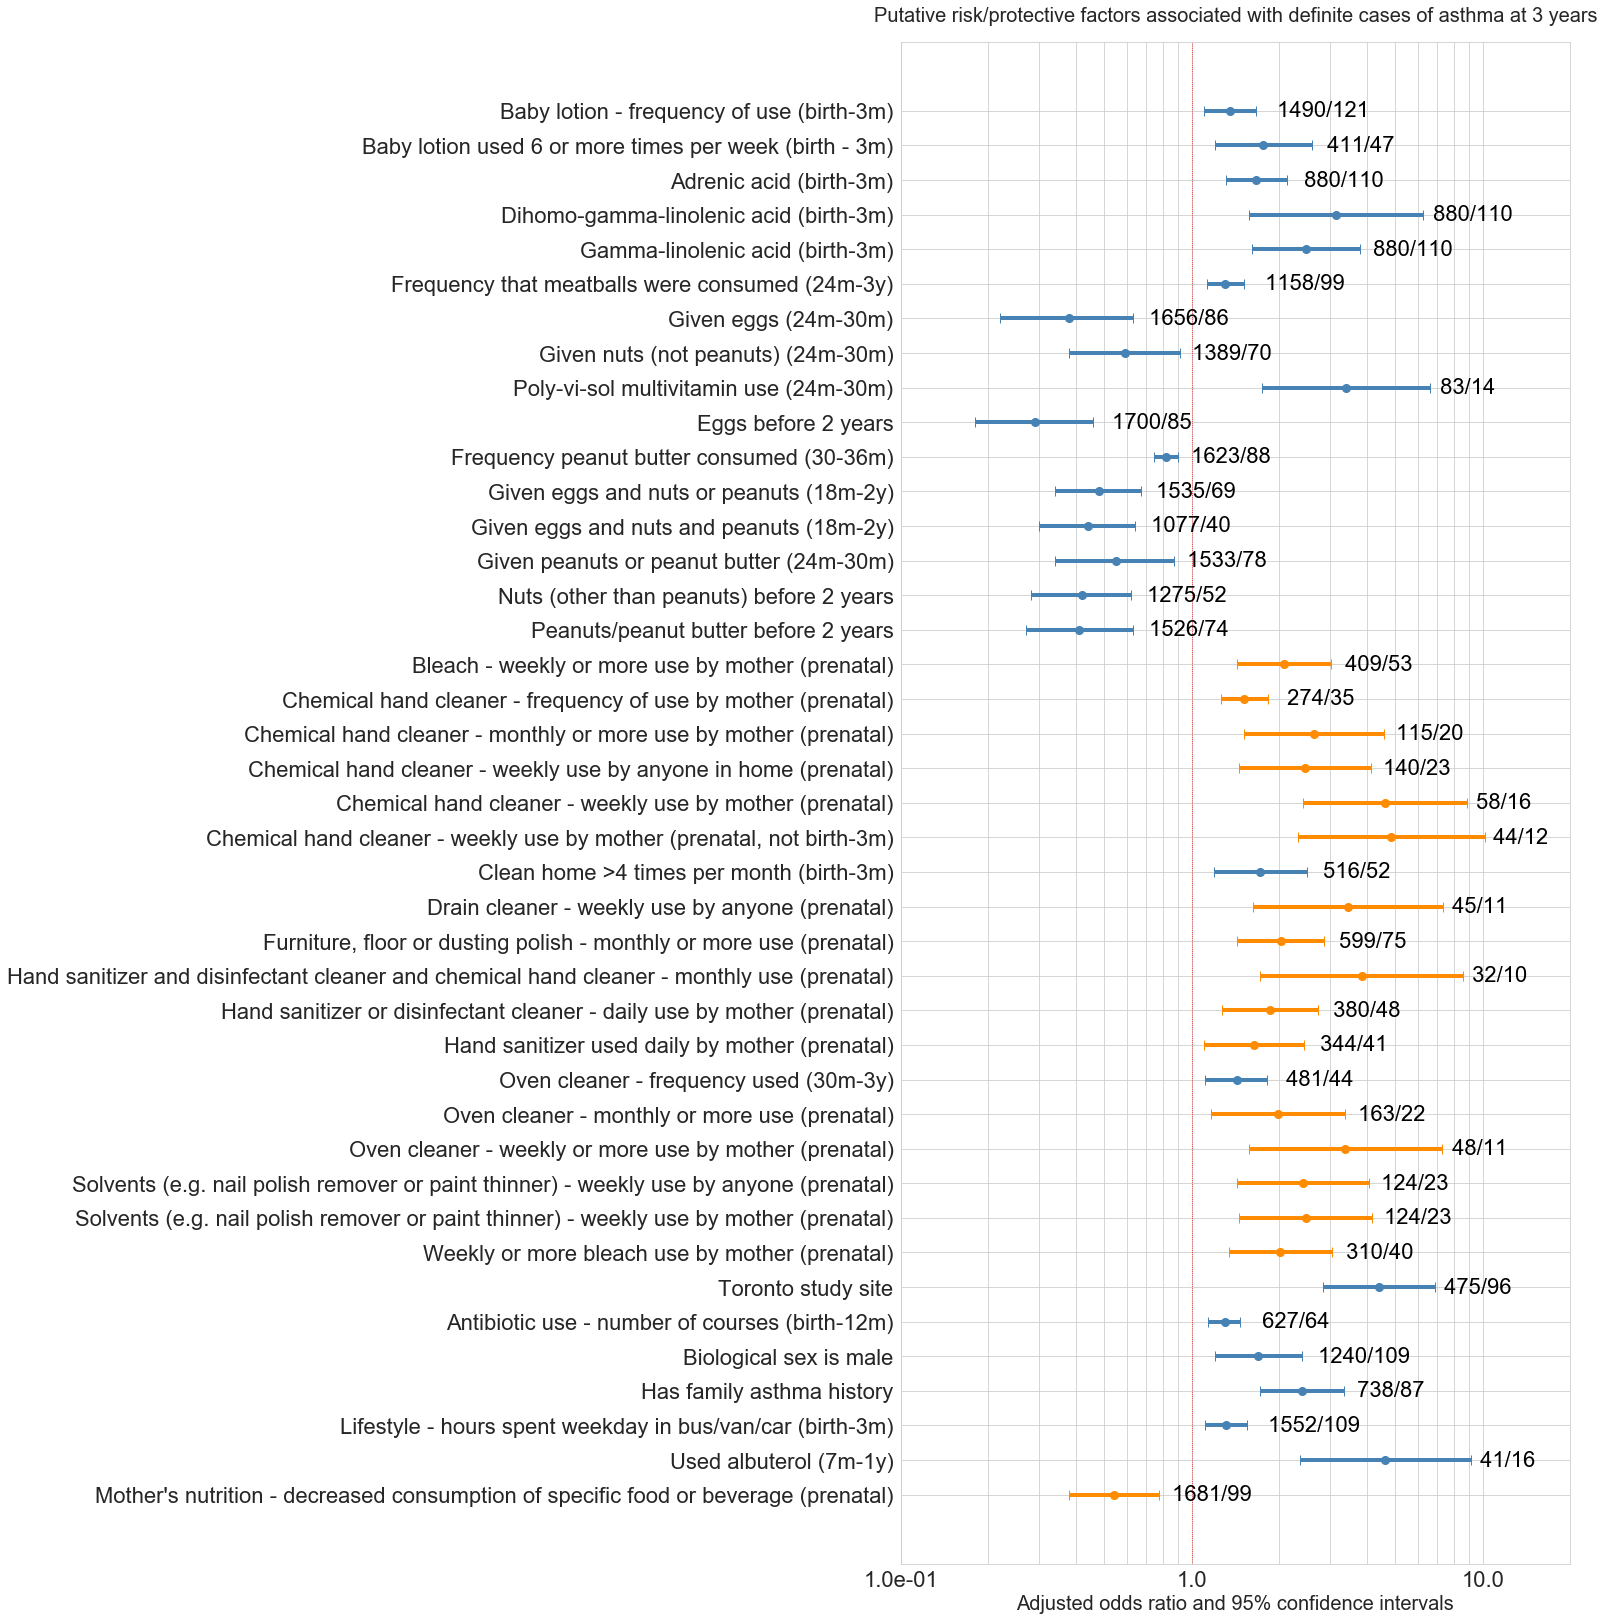

In [ ]:
odds_ratio_table = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_asthma_3y.csv")
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(12, 28))
plt.title("Putative risk/protective factors associated with definite cases of asthma at 3 years",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

        row['exposure'] = row['exposure'].replace("Breast milk - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Child nutrition - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Cleaners - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Phthalate exposure - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Medications - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Covariate - ","").capitalize()
        row['exposure'] = row['exposure'].replace(" (all-cis-docosa-7,10,13,16-tetraenoic acid)","").capitalize()
        row['exposure'] = row['exposure'].replace(" (vitamins a, c, d, b1, b2, b3, b6)","").capitalize()
        row['exposure'] = row['exposure'].replace("dehp","DEHP")
        row['exposure'] = row['exposure'].replace("(prenatal, not 6m-12m","(prenatal, not 6m-12m)")


        if row['time outcome assessed']=='3 Years' and row['total cases with exposure']>=10:
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if row['q'] < 0.05 and (row['OR']>1.1 or row['OR']<0.9) and row['OR']<10:
                label = str(row['OR'])
                if "prenatal" in row['exposure']:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='darkorange', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="darkorange", mec="darkorange")
                else:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='steelblue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="steelblue", mec="steelblue")
            #else:
            #    label = str(row['OR'])
            #    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:grey', capsize=5, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:grey", mec="tab:grey")

                label = " " + str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])
            # Add text to the right of the error bar
                if row['OR']>1.1:
                    plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=22)
                else:
                    plt.text(row['OR'] + ci[1][0] + 0.05, row['exposure'], f'{label}', color='black', va='center', fontsize=22)



#plt.xscale('log')
plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')



plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=22)


plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=20)

plt.xlim(0.1,20)


plt.show()

# Manuscript Supplementary Figure 4 -  Recurrent wheeze at 3 years (all signifcant exposures)

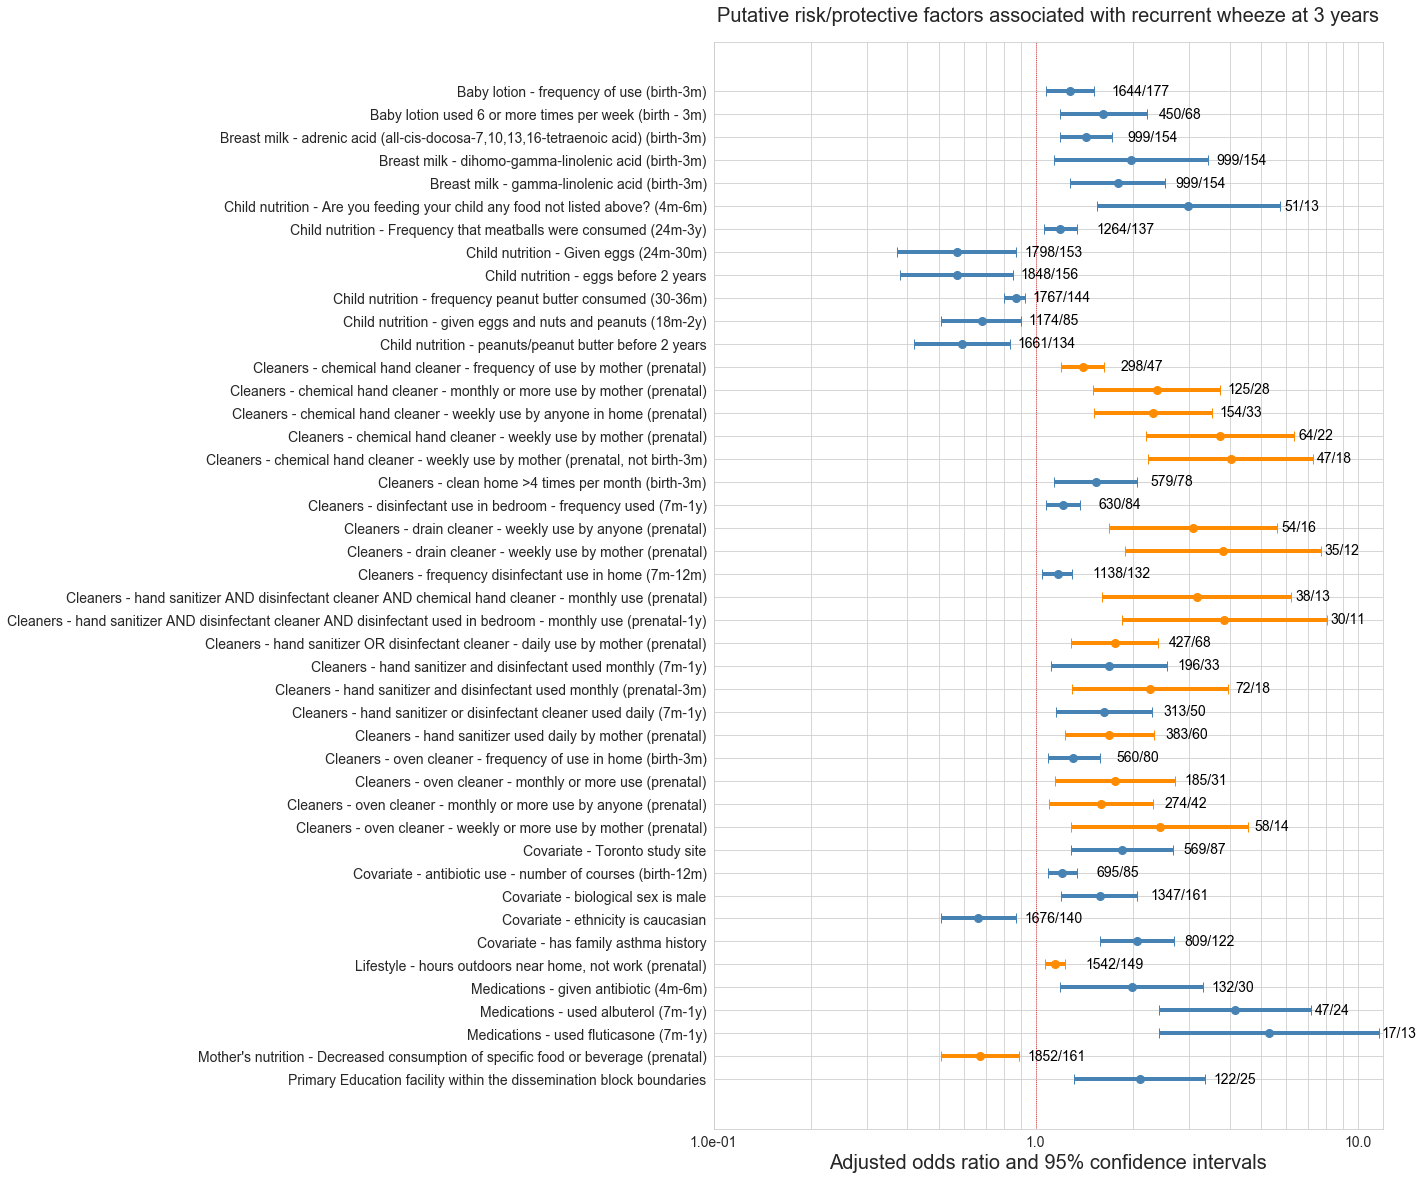

In [ ]:
odds_ratio_table = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_recurrent_wheeze_binary_3y.csv")
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(12, 20))
plt.title("Putative risk/protective factors associated with recurrent wheeze at 3 years",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():


        if row['time outcome assessed']=='3 Years' and row['total cases with exposure']>=10:
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if row['q'] < 0.05 and (row['OR']>1.1 or row['OR']<0.9) and row['OR']<10:
                label = str(row['OR'])
                if "prenatal" in row['exposure']:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='darkorange', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="darkorange", mec="darkorange")
                else:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='steelblue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="steelblue", mec="steelblue")
            #else:
            #    label = str(row['OR'])
            #    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:grey', capsize=5, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:grey", mec="tab:grey")

                label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])
            # Add text to the right of the error bar
                if row['OR']>1.1:
                    plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=14)
                else:
                    plt.text(row['OR'] + ci[1][0] + 0.05, row['exposure'], f'{label}', color='black', va='center', fontsize=14)



#plt.xscale('log')
plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')



plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)


plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=20)

plt.xlim(0.1,12)



plt.savefig('figures/round2_all_significant_variables_recurrent_wheeze_binary_3y.png')
plt.show()

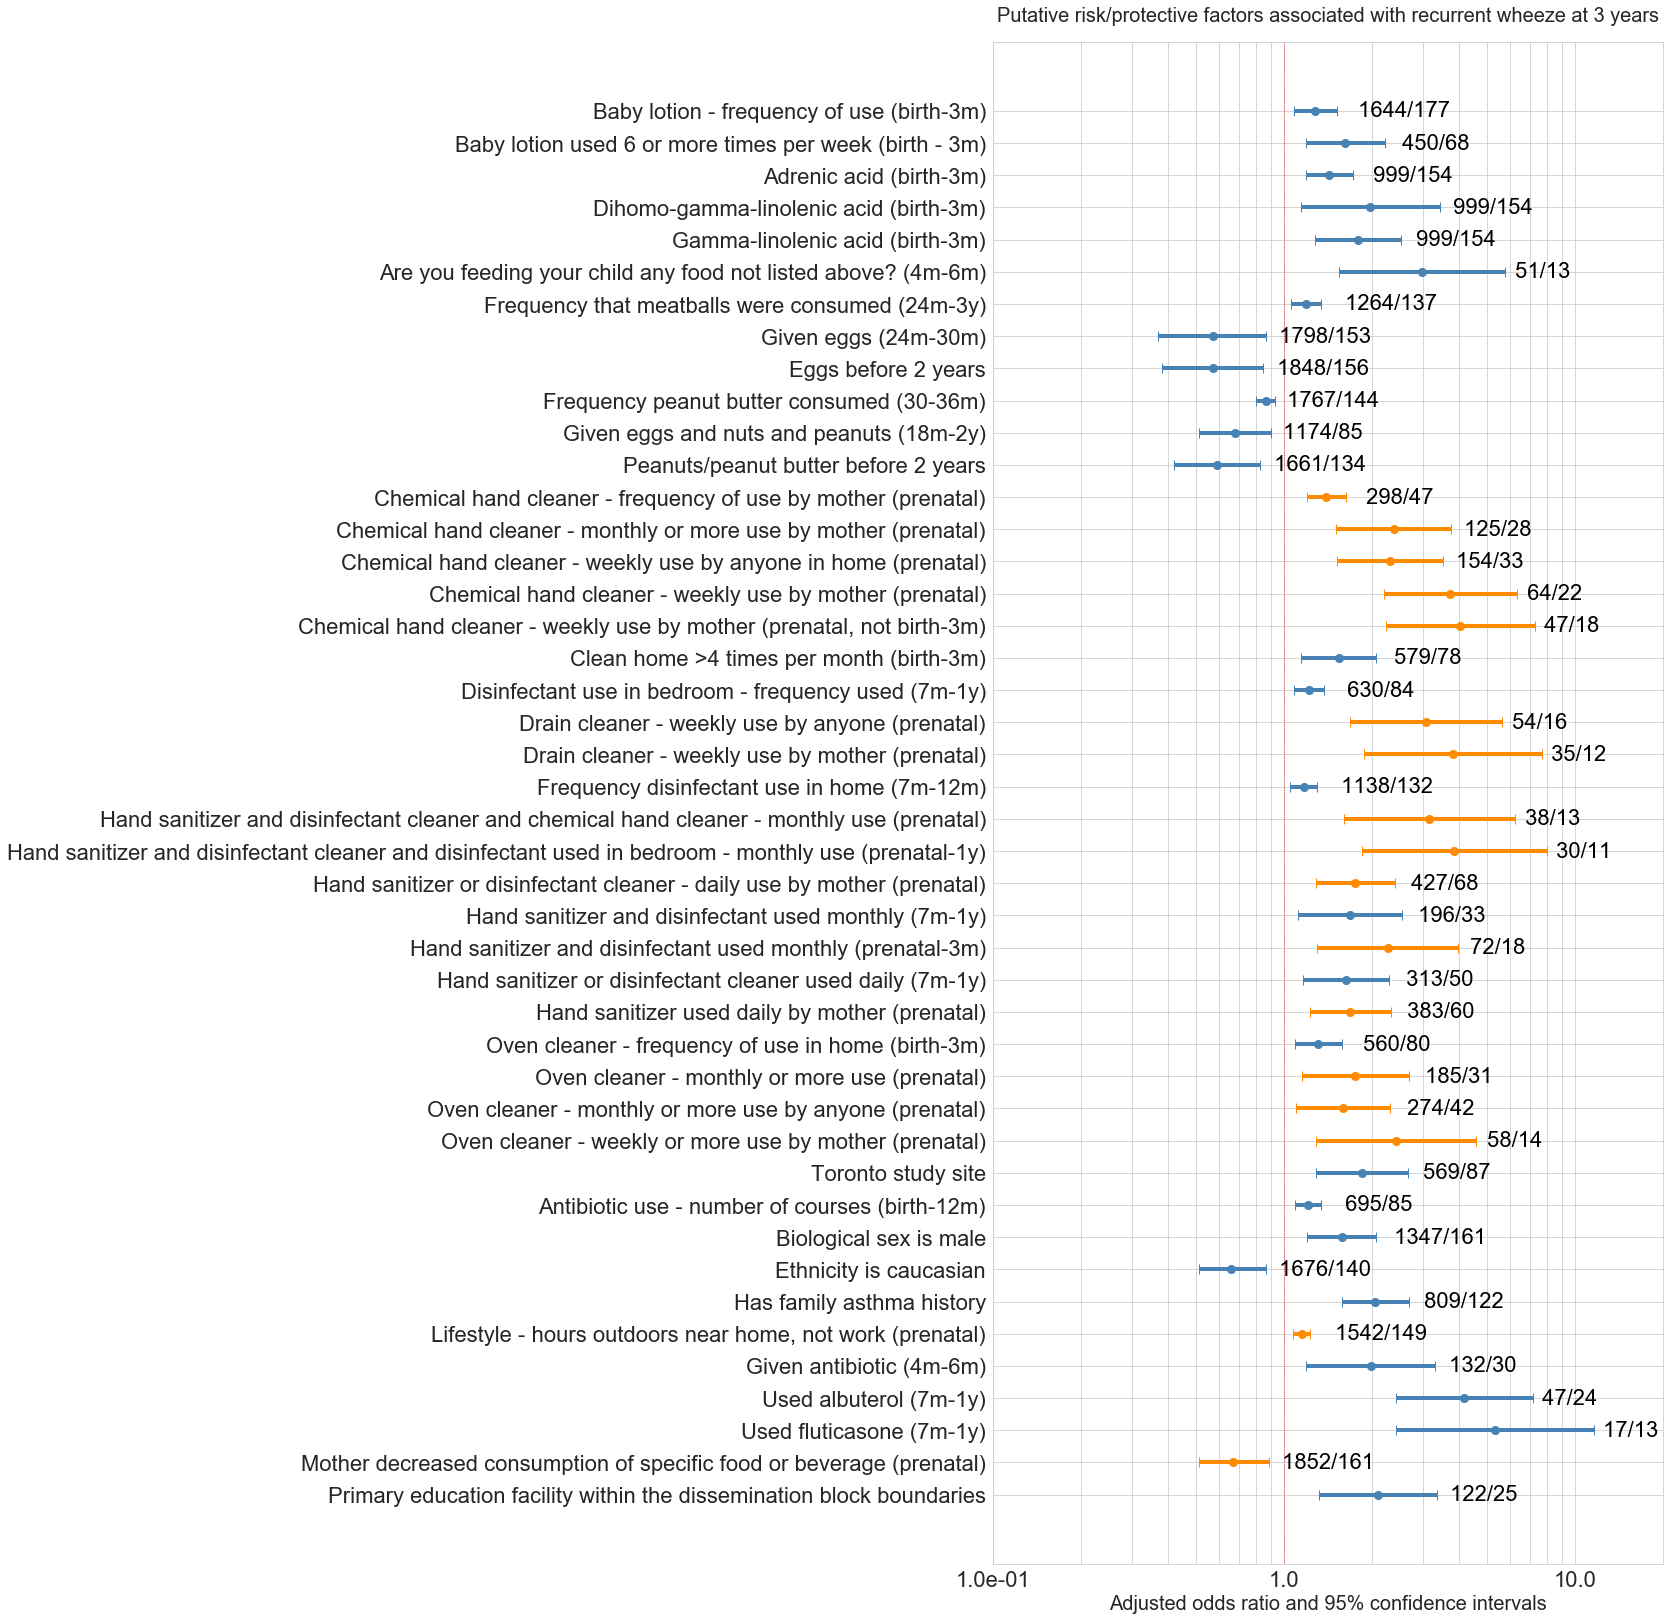

In [ ]:
odds_ratio_table = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_recurrent_wheeze_binary_3y.csv")
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(12, 28))
plt.title("Putative risk/protective factors associated with recurrent wheeze at 3 years",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

        row['exposure'] = row['exposure'].replace("Breast milk - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Mother's nutrition - ","Mother ").capitalize()
        row['exposure'] = row['exposure'].replace("Child nutrition - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Cleaners - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Phthalate exposure - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Medications - ","").capitalize()
        row['exposure'] = row['exposure'].replace("Covariate - ","").capitalize()
        row['exposure'] = row['exposure'].replace(" (all-cis-docosa-7,10,13,16-tetraenoic acid)","").capitalize()
        row['exposure'] = row['exposure'].replace(" (vitamins a, c, d, b1, b2, b3, b6)","").capitalize()
        row['exposure'] = row['exposure'].replace("dehp","DEHP")
        row['exposure'] = row['exposure'].replace("(prenatal, not 6m-12m","(prenatal, not 6m-12m)")


        if row['time outcome assessed']=='3 Years' and row['total cases with exposure']>=10:
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if row['q'] < 0.05 and (row['OR']>1.1 or row['OR']<0.9) and row['OR']<10:
                label = str(row['OR'])
                if "prenatal" in row['exposure']:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='darkorange', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="darkorange", mec="darkorange")
                else:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='steelblue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="steelblue", mec="steelblue")
            #else:
            #    label = str(row['OR'])
            #    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:grey', capsize=5, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:grey", mec="tab:grey")

                label = " " + str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])
            # Add text to the right of the error bar
                if row['OR']>1.1:
                    plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=22)
                else:
                    plt.text(row['OR'] + ci[1][0] + 0.05, row['exposure'], f'{label}', color='black', va='center', fontsize=22)



#plt.xscale('log')
plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')



plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=22)


plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=20)

plt.xlim(0.1,20)


plt.show()

# Manuscript Supplementary Figure 2 - Recurrent wheeze at 1 year (all significant exposures)

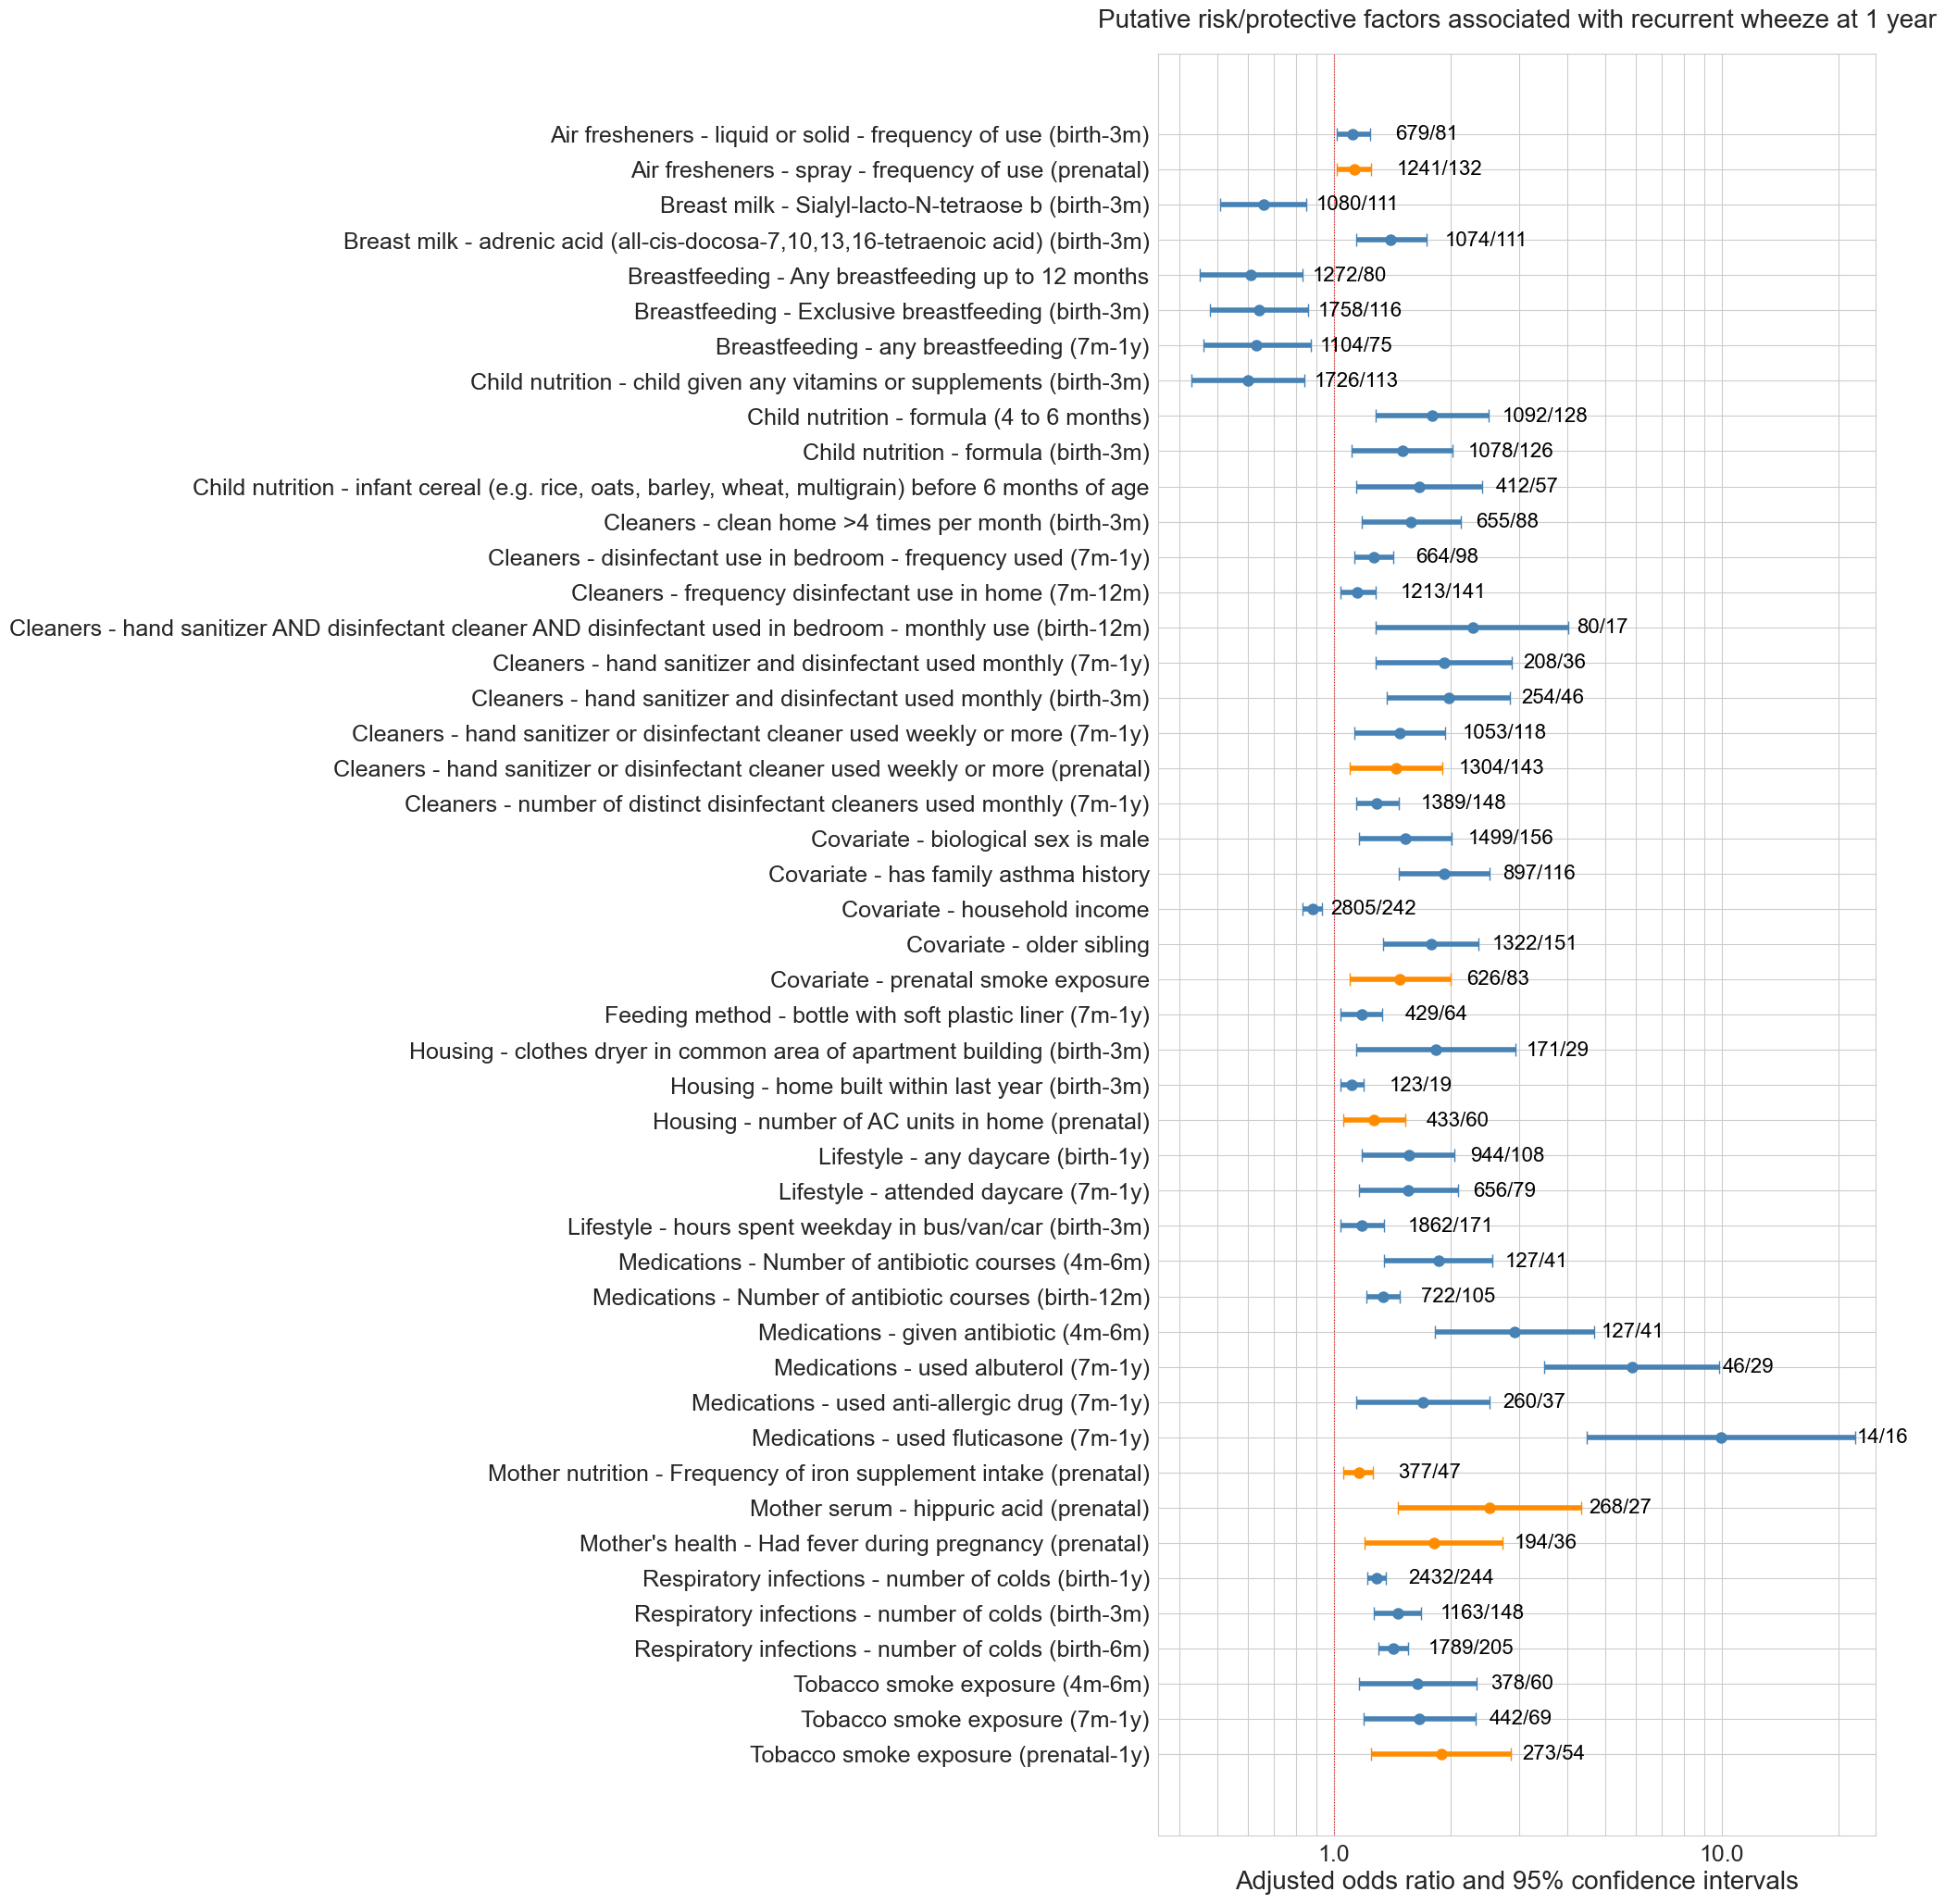

In [280]:
odds_ratio_table = pd.read_csv("odds-ratios/round2_significant_exposures_1_Year_recurrent_wheeze_binary_1y.csv")
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
      odds_ratio_table.loc[idx,"exposure"]= row['exposure'].replace("Food products","Child nutrition").replace("Vitamins or supplements","Child nutrition")


odds_ratio_table = odds_ratio_table.sort_values(by="exposure")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(10, 25))
plt.title("Putative risk/protective factors associated with recurrent wheeze at 1 year",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():


        #row['exposure'] = row['exposure'].replace("Food products","Child nutrition").replace("Vitamins or supplements","Child nutrition")


        if row['time outcome assessed']=='1 Year' and row['total cases with exposure']>=10:
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if row['q'] < 0.05 and (row['OR']>1.1 or row['OR']<0.9) and row['OR']<10:
                label = str(row['OR'])
                if "prenatal" in row['exposure']:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='darkorange', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="darkorange", mec="darkorange")
                else:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='steelblue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="steelblue", mec="steelblue")
            #else:
            #    label = str(row['OR'])
            #    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:grey', capsize=5, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:grey", mec="tab:grey")

                label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])
            # Add text to the right of the error bar
                if row['OR']>1.1:
                    plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=16)
                else:
                    plt.text(row['OR'] + ci[1][0] + 0.05, row['exposure'], f'{label}', color='black', va='center', fontsize=16)



#plt.xscale('log')
plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')



plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=18)


plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=20)

plt.xlim(0,25)


plt.savefig('figures/round2_all_significant_variables_recurrent_wheeze_binary_1y.png')
plt.show()

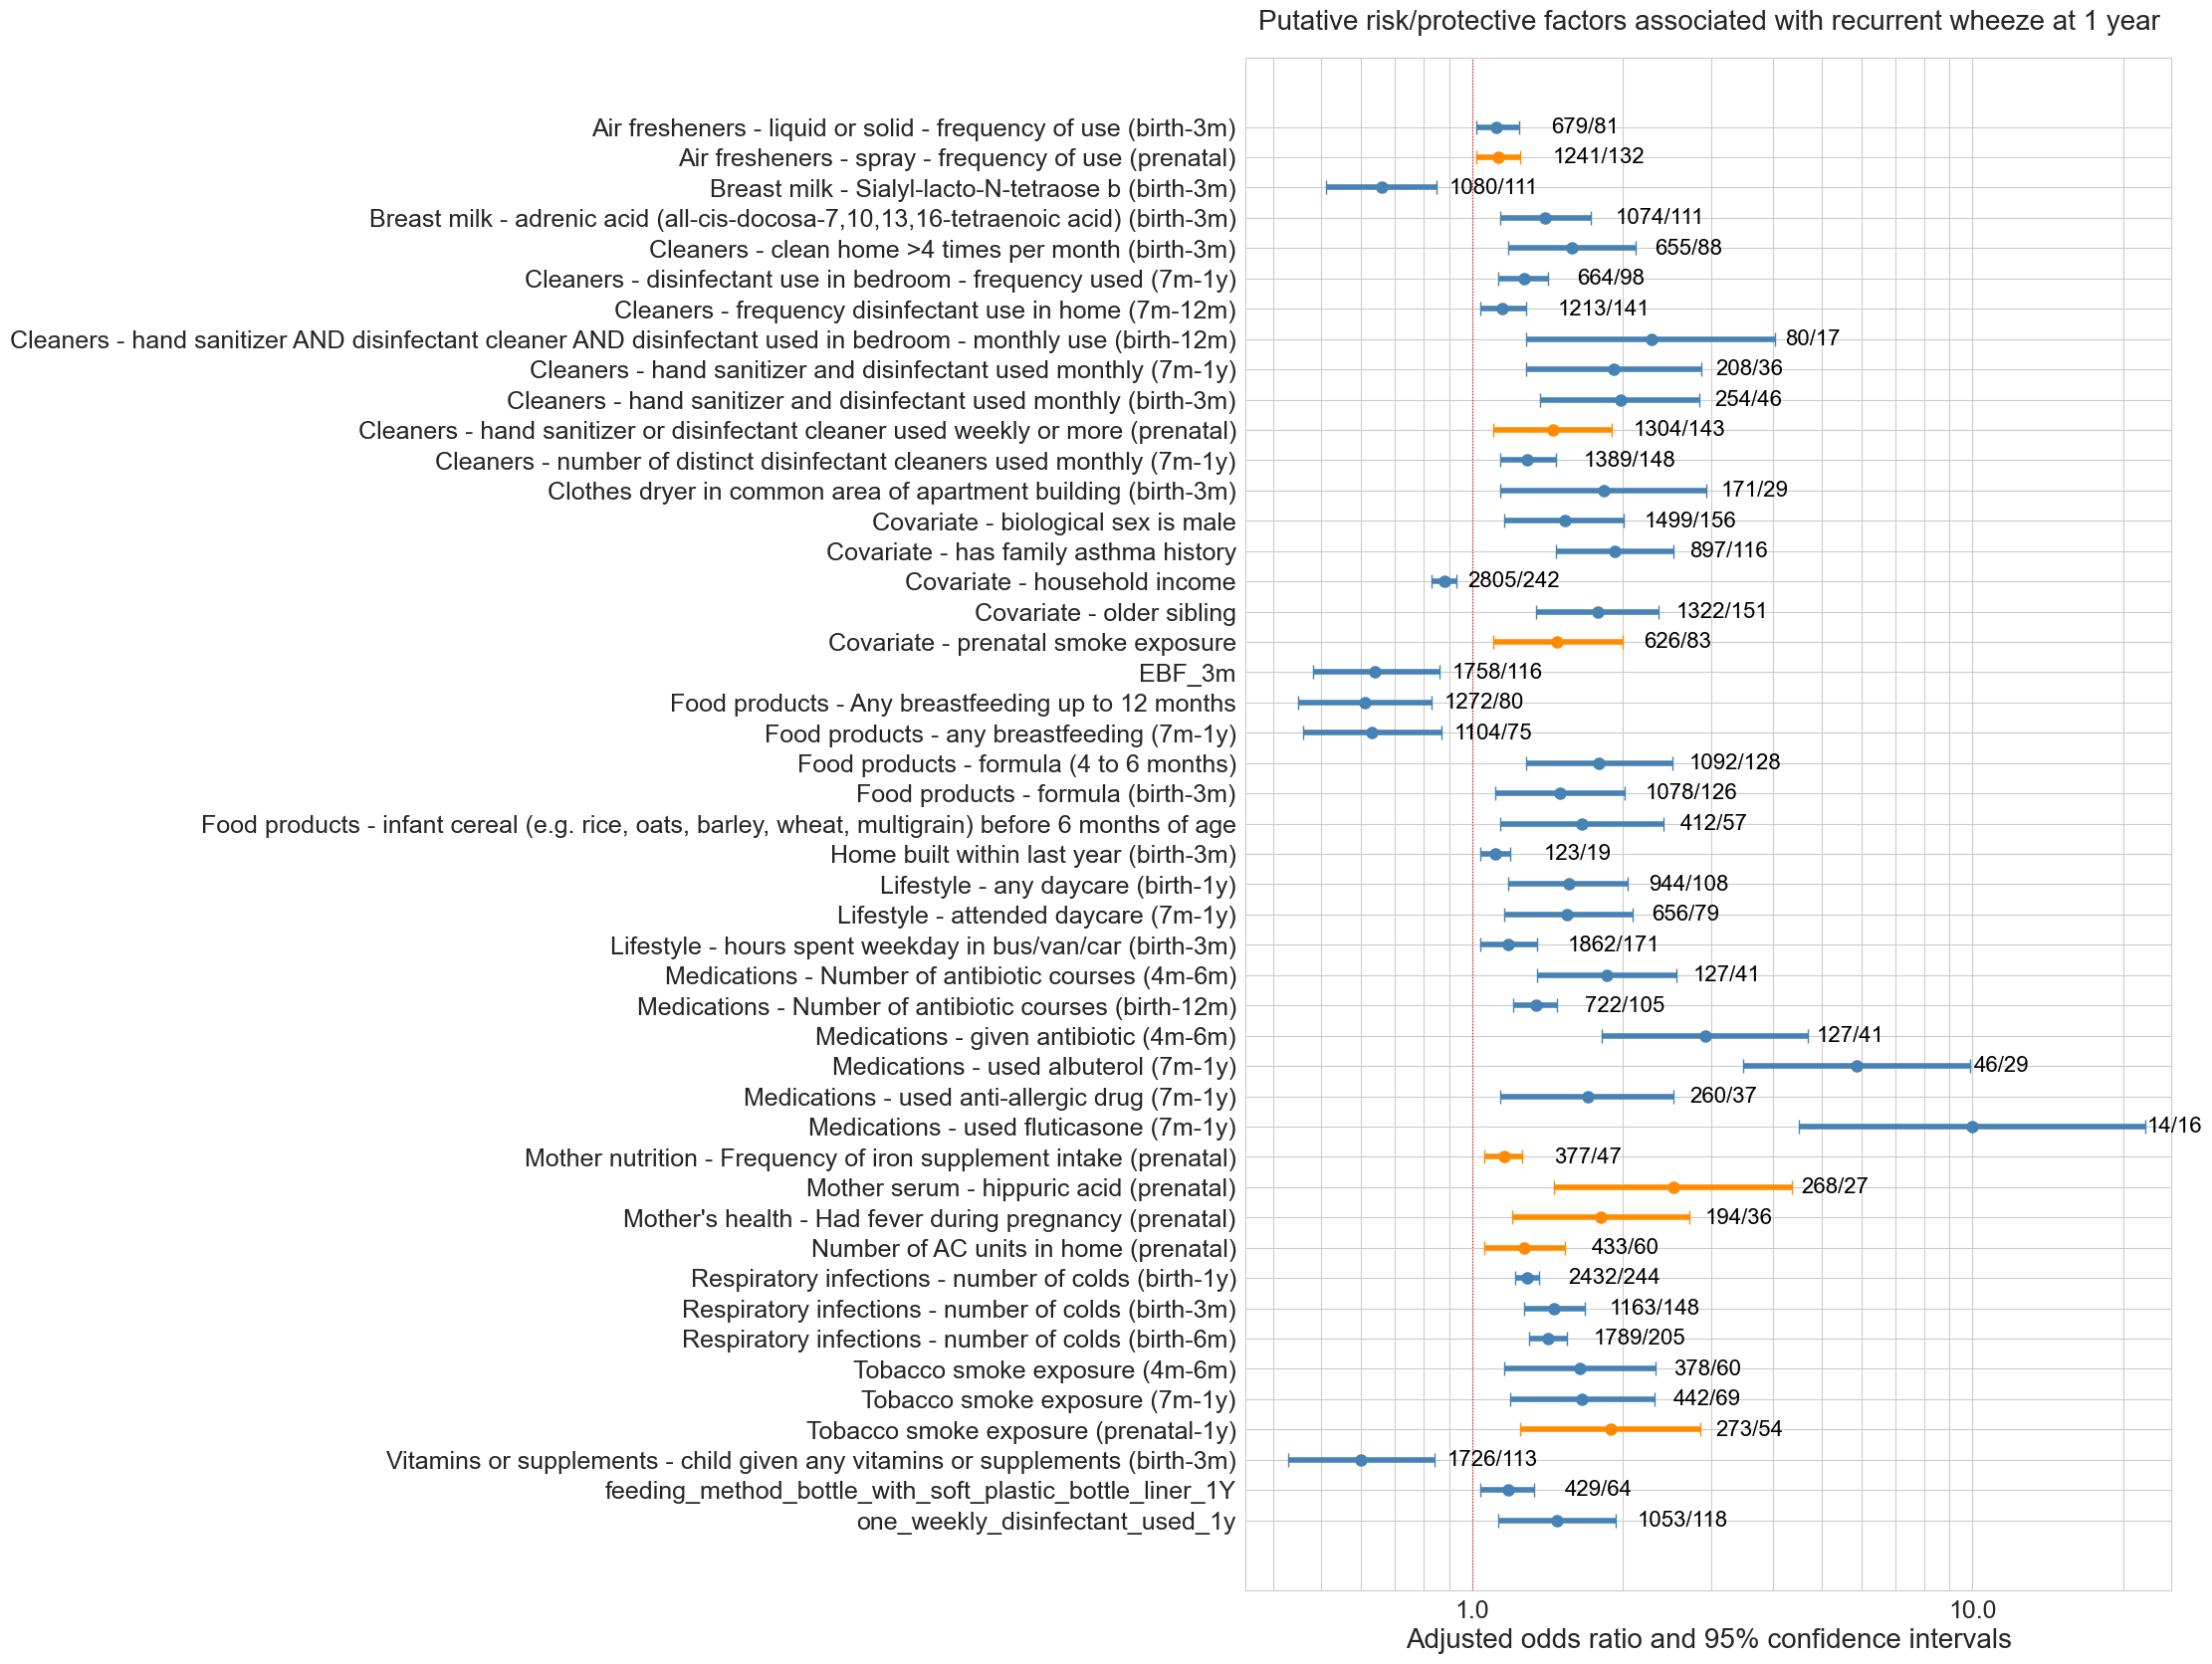

In [22]:
odds_ratio_table = pd.read_csv("odds-ratios/round2_significant_exposures_1_Year_recurrent_wheeze_binary_1y.csv")

odds_ratio_table = odds_ratio_table.sort_values(by="exposure")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(12, 20))
plt.title("Putative risk/protective factors associated with recurrent wheeze at 1 year",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():


        if row['time outcome assessed']=='1 Year' and row['total cases with exposure']>=10:
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if row['q'] < 0.05 and (row['OR']>1.1 or row['OR']<0.9) and row['OR']<10:
                label = str(row['OR'])
                if "prenatal" in row['exposure']:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='darkorange', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="darkorange", mec="darkorange")
                else:
                    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='steelblue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="steelblue", mec="steelblue")
            #else:
            #    label = str(row['OR'])
            #    plt.errorbar(x=[row['OR']], y=[row['exposure']], xerr=ci, ecolor='tab:grey', capsize=5, linestyle='None', linewidth=1, marker="o", markersize=8, mfc="tab:grey", mec="tab:grey")

                label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure'])
            # Add text to the right of the error bar
                if row['OR']>1.1:
                    plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure'], f'{label}', color='black', va='center', fontsize=16)
                else:
                    plt.text(row['OR'] + ci[1][0] + 0.05, row['exposure'], f'{label}', color='black', va='center', fontsize=16)



#plt.xscale('log')
plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')



plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=18)


plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=20)

plt.xlim(0,25)


plt.savefig('figures/round2_all_significant_variables_recurrent_wheeze_binary_1y.png')
plt.show()

In [ ]:
df = allframes[(allframes["exposure"].str.contains("hand cleaner")) & (allframes["outcome"].str.contains("Asthma") | allframes["outcome"].str.contains("wheeze at") ) ]
df = df[df['exposure']!='Cleaners - hand sanitizer AND disinfectant cleaner AND chemical hand cleaner - monthly use (prenatal)']

for index, row in df.iterrows():
    
    if row['reject_null']==True and row['total cases with exposure']>=10:
        full_or = str(row['OR']) + " ("+str(row['Lower CI'])+ " - "+str(row['Upper CI'])+")"
    else:
        full_or = ""

    time_outcome_assessed = row['time outcome assessed']
    #time_outcome_assessed = time_outcome_assessed.replace(" Years","y").replace(" Year","y")
    
    exposure = row['exposure']
    exposure = exposure.replace("Cleaners - ","")
    exposure = exposure.replace("chemical hand cleaner - ","")
    outcome = row['outcome']
    outcome = outcome.replace("Asthma (definite cases, clinician) at 3 years","Definite asthma")
    outcome = outcome.replace("Asthma (definite cases, clinician) at 5 years","Definite asthma")
    outcome = outcome.replace("Asthma (definite cases, clinician) at 8 years","Definite asthma")
    outcome = outcome.replace("Asthma (definite and possible cases, clinician) at 3 years","Definite or possible asthma")
    outcome = outcome.replace("Asthma (definite and possible cases, clinician) at 5 years","Definite or possible asthma")
    outcome = outcome.replace("Asthma (definite and possible cases, clinician) at 8 years","Definite or possible asthma")
    outcome = outcome.replace("Recurrent wheeze at 1y","Recurrent wheeze")
    outcome = outcome.replace("Recurrent wheeze at 3y","Recurrent wheeze")
    outcome = outcome.replace("Recurrent wheeze at 5y","Recurrent wheeze")
    df.loc[index,"exposure"]=exposure
    df.loc[index,"outcome"]=outcome
    df.loc[index,"time outcome assessed"]=time_outcome_assessed

    df.loc[index,"OR2"]=full_or

pivot_table_frames = pd.pivot_table(df, index=["exposure","time outcome assessed"], columns=["outcome"], values="OR2", aggfunc=lambda x: ' '.join(x))
pivot_table_frames.replace(np.nan,"",inplace=True)
pivot_table_frames.to_excel("manuscript/chemical_hand_cleaner_OR_table.xlsx")
pivot_table_frames.sort_values(by=['exposure'])


outcome                                                                  Definite asthma  \
exposure                                      time outcome assessed                        
daily use by anyone in home (prenatal)        3 Years                                      
frequency of use by mother (prenatal)         3 Years                 1.52 (1.26 - 1.83)   
                                              5 Years                 1.54 (1.28 - 1.84)   
                                              8 Years                  1.36 (1.1 - 1.69)   
monthly or more use by mother (prenatal)      3 Years                  2.64 (1.51 - 4.6)   
                                              5 Years                  3.05 (1.79 - 5.2)   
                                              8 Years                 2.47 (1.32 - 4.61)   
weekly use by anyone in home (prenatal)       5 Years                 2.71 (1.64 - 4.48)   
                                              3 Years                 2.46 (1.46 - 4.13)   
weekly use by mother (prenatal)               3 Years                 4.62 (2.42 - 8.82)   
                                              5 Years                 5.09 (2.74 - 9.42)   
                                              8 Years                 3.94 (1.91 - 8.14)   
weekly use by mother (prenatal, not 6m-12m    5 Years                  3.63 (1.71 - 7.7)   
                                              8 Years                                      
weekly use by mother (prenatal, not birth-3m) 5 Years                5.17 (2.57 - 10.39)   
                                              3 Years                4.86 (2.32 - 10.19)   
                                              8 Years                6.55 (3.05 - 14.04)   

outcome                                                             Definite or possible asthma  \
exposure                                      time outcome assessed                               
daily use by anyone in home (prenatal)        3 Years                        2.94 (1.58 - 5.46)   
frequency of use by mother (prenatal)         3 Years                          1.3 (1.12 - 1.5)   
                                              5 Years                        1.25 (1.08 - 1.44)   
                                              8 Years                                             
monthly or more use by mother (prenatal)      3 Years                        1.87 (1.21 - 2.88)   
                                              5 Years                        1.75 (1.15 - 2.68)   
                                              8 Years                                             
weekly use by anyone in home (prenatal)       5 Years                                             
                                              3 Years                        2.02 (1.37 - 2.98)   
weekly use by mother (prenatal)               3 Years                        2.84 (1.69 - 4.77)   
                                              5 Years                         2.54 (1.5 - 4.29)   
                                              8 Years                        3.27 (1.79 - 5.99)   
weekly use by mother (prenatal, not 6m-12m    5 Years                                             
                                              8 Years                        4.55 (2.31 - 8.98)   
weekly use by mother (prenatal, not birth-3m) 5 Years                         2.6 (1.43 - 4.75)   
                                              3 Years                          2.9 (1.6 - 5.27)   
                                              8 Years                       5.39 (2.83 - 10.27)   

outcome                                                                Recurrent wheeze  
exposure                                      time outcome assessed                      
daily use by anyone in home (prenatal)        3 Years                                    
frequency of use by mother (prenatal)         3 Years                  1.4 (1.2 - 1.63)  
         

# WALD TESTS

# Wald test for antibiotic use versus weekly prenatal oven cleaner,

In [ ]:
# weekly_oven_cleaner_use_mother_prenatal
# weekly_chem_hand_cleaner_use_mother_prenatal
# num_antibiotic_courses_birth_to_1y



import statsmodels.formula.api as smf

# Filter out missing values for both exposures
subjects = subjects[~subjects['num_antibiotic_courses_birth_to_1y'].isna()]
subjects = subjects[~subjects['weekly_oven_cleaner_use_mother_prenatal'].isna()]

# Define covariates
covariates = [
    'family_asthma_history', 'older_children_in_home_3m', 
    'total_household_income_PR18WK', 'EBF_6m', 'vaginal_birth', 
    'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth',
    'site_toronto', 'site_vancouver', 'site_edmonton',
    'is_male', 'is_caucasian'
]

# Build formula for logistic regression
formula = (
    'asthma_5y ~ num_antibiotic_courses_birth_to_1y + '
    'weekly_oven_cleaner_use_mother_prenatal + ' + ' + '.join(covariates)
)

# Fit logistic regression
model = smf.logit(formula, data=subjects).fit()

# Wald test: H0 = coefficients for antibiotics and oven cleaner are equal
# Null hypothesis: β_antibiotics - β_oven_cleaner = 0
R = [[0, 1, -1] + [0] * len(covariates)]  # Intercept=0, abx=1, oven=-1, covariates=0
wald_test = model.wald_test(R)


#print(model.summary())

params = model.params
conf = model.conf_int()
or_table = np.exp(params)
or_ci = np.exp(conf)
print(pd.DataFrame({'OR': or_table, '2.5%': or_ci[0], '97.5%': or_ci[1]}))

print("\nWald test result:")
print(wald_test)


Optimization terminated successfully.
         Current function value: 0.479105
         Iterations 6
                                               OR      2.5%     97.5%
Intercept                                0.132110  0.037026  0.471373
num_antibiotic_courses_birth_to_1y       1.229758  1.044333  1.448105
weekly_oven_cleaner_use_mother_prenatal  2.922448  0.866318  9.858626
family_asthma_history                    2.464763  1.566723  3.877557
older_children_in_home_3m                0.887485  0.564517  1.395228
total_household_income_PR18WK            0.982775  0.875476  1.103224
EBF_6m                                   0.784391  0.424244  1.450274
vaginal_birth                            0.661303  0.407257  1.073822
prenatal_smoke_exposure                  1.315770  0.785521  2.203954
summer_birth                             1.630887  0.886374  3.000758
winter_birth                             0.977665  0.518469  1.843558
autumn_birth                             1.120624  0.60751

# Wald test for antibiotic use versus weekly chemical hand cleaner

In [ ]:

import statsmodels.formula.api as smf

# Filter out missing values for both exposures
subjects = subjects[~subjects['num_antibiotic_courses_birth_to_1y'].isna()]
subjects = subjects[~subjects['weekly_chem_hand_cleaner_use_mother_prenatal'].isna()]

# Define covariates
covariates = [
    'family_asthma_history', 'older_children_in_home_3m', 
    'total_household_income_PR18WK', 'EBF_6m', 'vaginal_birth', 
    'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth',
    'site_toronto', 'site_vancouver', 'site_edmonton',
    'is_male', 'is_caucasian'
]

# Build formula for logistic regression
formula = (
    'asthma_5y ~ num_antibiotic_courses_birth_to_1y + '
    'weekly_chem_hand_cleaner_use_mother_prenatal + ' + ' + '.join(covariates)
)

# Fit logistic regression
model = smf.logit(formula, data=subjects).fit()

# Wald test: H0 = coefficients for antibiotics and weekly_chem_hand_cleaner_use_mother_prenatal are equal
# Null hypothesis: β_antibiotics - β_oven_cleaner = 0
R = [[0, 1, -1] + [0] * len(covariates)]  # Intercept=0, abx=1, oven=-1, covariates=0
wald_test = model.wald_test(R)


#print(model.summary())

params = model.params
conf = model.conf_int()
or_table = np.exp(params)
or_ci = np.exp(conf)
print(pd.DataFrame({'OR': or_table, '2.5%': or_ci[0], '97.5%': or_ci[1]}))


print("\nWald test result:")
print(wald_test)


Optimization terminated successfully.
         Current function value: 0.476063
         Iterations 6
                                                    OR      2.5%     97.5%
Intercept                                     0.131514  0.037641  0.459500
num_antibiotic_courses_birth_to_1y            1.241530  1.052421  1.464620
weekly_chem_hand_cleaner_use_mother_prenatal  3.123751  1.290640  7.560449
family_asthma_history                         2.466022  1.566230  3.882742
older_children_in_home_3m                     0.906247  0.575401  1.427324
total_household_income_PR18WK                 0.989517  0.881677  1.110548
EBF_6m                                        0.807443  0.434973  1.498860
vaginal_birth                                 0.633728  0.390517  1.028410
prenatal_smoke_exposure                       1.284683  0.767423  2.150586
summer_birth                                  1.604329  0.872160  2.951146
winter_birth                                  0.957251  0.507045  1.80719

# Wald test for antibiotic use versus dust DEHP levels at 3 months of age (log_dehp_bc_rec_dust_3m)

In [ ]:

import statsmodels.formula.api as smf

# Filter out missing values for both exposures
subjects = subjects[~subjects['num_antibiotic_courses_birth_to_1y'].isna()]
subjects = subjects[~subjects['log_dehp_bc_rec_dust_3m'].isna()]

# Define covariates
covariates = [
    'family_asthma_history', 'older_children_in_home_3m', 
    'total_household_income_PR18WK', 'EBF_6m', 'vaginal_birth', 
    'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth',
    'site_toronto', 'site_vancouver', 'site_edmonton',
    'is_male', 'is_caucasian'
]

# Build formula for logistic regression
formula = (
    'asthma_5y ~ num_antibiotic_courses_birth_to_1y + '
    'log_dehp_bc_rec_dust_3m + ' + ' + '.join(covariates)
)

# Fit logistic regression
model = smf.logit(formula, data=subjects).fit()

# Wald test: H0 = coefficients for antibiotics and log_dehp_bc_rec_dust_3m are equal
# Null hypothesis: β_antibiotics - β_oven_cleaner = 0
R = [[0, 1, -1] + [0] * len(covariates)]  # Intercept=0, abx=1, oven=-1, covariates=0
wald_test = model.wald_test(R)

#print(model.summary())

params = model.params
conf = model.conf_int()
or_table = np.exp(params)
or_ci = np.exp(conf)
print(pd.DataFrame({'OR': or_table, '2.5%': or_ci[0], '97.5%': or_ci[1]}))

print("\nWald test result:")
print(wald_test)


Optimization terminated successfully.
         Current function value: 0.463291
         Iterations 6
                                          OR      2.5%     97.5%
Intercept                           0.003148  0.000328  0.030179
num_antibiotic_courses_birth_to_1y  1.212238  1.026652  1.431373
log_dehp_bc_rec_dust_3m             1.977353  1.448502  2.699290
family_asthma_history               2.346962  1.482588  3.715281
older_children_in_home_3m           0.790774  0.497257  1.257546
total_household_income_PR18WK       0.999534  0.890156  1.122352
EBF_6m                              0.761665  0.409183  1.417787
vaginal_birth                       0.709640  0.433269  1.162301
prenatal_smoke_exposure             1.151313  0.680817  1.946956
summer_birth                        1.596640  0.853219  2.987814
winter_birth                        0.917839  0.479960  1.755207
autumn_birth                        1.060569  0.569751  1.974207
site_toronto                        1.319172  0.68588

# Wald test for antibiotic use versus daily prenatal hand sanitizer use (daily_hand_sanitizer_used_prenatal)

In [ ]:

import statsmodels.formula.api as smf

# Filter out missing values for both exposures
subjects = subjects[~subjects['num_antibiotic_courses_birth_to_1y'].isna()]
subjects = subjects[~subjects['daily_hand_sanitizer_used_prenatal'].isna()]

# Define covariates
covariates = [
    'family_asthma_history', 'older_children_in_home_3m', 
    'total_household_income_PR18WK', 'EBF_6m', 'vaginal_birth', 
    'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth',
    'site_toronto', 'site_vancouver', 'site_edmonton',
    'is_male', 'is_caucasian'
]

# Build formula for logistic regression
formula = (
    'asthma_5y ~ num_antibiotic_courses_birth_to_1y + '
    'daily_hand_sanitizer_used_prenatal + ' + ' + '.join(covariates)
)

# Fit logistic regression
model = smf.logit(formula, data=subjects).fit()

# Wald test: H0 = coefficients for antibiotics and daily_hand_sanitizer_used_prenatal are equal
# Null hypothesis: β_antibiotics - β_oven_cleaner = 0
R = [[0, 1, -1] + [0] * len(covariates)]  # Intercept=0, abx=1, oven=-1, covariates=0
wald_test = model.wald_test(R)

print(model.summary())

params = model.params
conf = model.conf_int()
or_table = np.exp(params)
or_ci = np.exp(conf)
print(pd.DataFrame({'OR': or_table, '2.5%': or_ci[0], '97.5%': or_ci[1]}))

print("\nWald test result:")
print(wald_test)


Optimization terminated successfully.
         Current function value: 0.232696
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              asthma_5y   No. Observations:                 2083
Model:                          Logit   Df Residuals:                     2066
Method:                           MLE   Df Model:                           16
Date:                Tue, 12 Aug 2025   Pseudo R-squ.:                 0.07434
Time:                        22:19:30   Log-Likelihood:                -484.71
converged:                       True   LL-Null:                       -523.64
Covariance Type:            nonrobust   LLR p-value:                 4.037e-10
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -3.0648      0.491    

# Wald test for antibiotic use versus weekly chemical hand cleaner and asthma at 8 years

In [ ]:

import statsmodels.formula.api as smf

# Filter out missing values for both exposures
subjects = subjects[~subjects['num_antibiotic_courses_birth_to_1y'].isna()]
subjects = subjects[~subjects['weekly_chem_hand_cleaner_use_mother_prenatal'].isna()]

# Define covariates
covariates = [
    'family_asthma_history', 'older_children_in_home_3m', 
    'total_household_income_PR18WK', 'EBF_6m', 'vaginal_birth', 
    'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth',
    'site_toronto', 'site_vancouver', 'site_edmonton',
    'is_male', 'is_caucasian'
]

# Build formula for logistic regression
formula = (
    'asthma_8y ~ num_antibiotic_courses_birth_to_1y + '
    'weekly_chem_hand_cleaner_use_mother_prenatal + ' + ' + '.join(covariates)
)

# Fit logistic regression
model = smf.logit(formula, data=subjects).fit()

# Wald test: H0 = coefficients for antibiotics and weekly_chem_hand_cleaner_use_mother_prenatal are equal
# Null hypothesis: β_antibiotics - β_oven_cleaner = 0
R = [[0, 1, -1] + [0] * len(covariates)]  # Intercept=0, abx=1, oven=-1, covariates=0
wald_test = model.wald_test(R)


#print(model.summary())

params = model.params
conf = model.conf_int()
or_table = np.exp(params)
or_ci = np.exp(conf)
print(pd.DataFrame({'OR': or_table, '2.5%': or_ci[0], '97.5%': or_ci[1]}))


print("\nWald test result:")
print(wald_test)


Optimization terminated successfully.
         Current function value: 0.198090
         Iterations 7
                                                    OR      2.5%      97.5%
Intercept                                     0.077084  0.026900   0.220892
num_antibiotic_courses_birth_to_1y            1.322140  1.158857   1.508430
weekly_chem_hand_cleaner_use_mother_prenatal  4.731376  2.106079  10.629195
family_asthma_history                         2.602143  1.747200   3.875427
older_children_in_home_3m                     0.810508  0.541784   1.212519
total_household_income_PR18WK                 0.972631  0.883226   1.071086
EBF_6m                                        0.834529  0.477241   1.459300
vaginal_birth                                 0.746483  0.478904   1.163569
prenatal_smoke_exposure                       1.306913  0.836179   2.042651
summer_birth                                  0.804198  0.450211   1.436512
winter_birth                                  1.026097  0.6015

# Wald test for antibiotic use versus weekly prenatal oven cleaner and asthma at 8 years

In [ ]:

import statsmodels.formula.api as smf

# Filter out missing values for both exposures
subjects = subjects[~subjects['num_antibiotic_courses_birth_to_1y'].isna()]
subjects = subjects[~subjects['weekly_oven_cleaner_use_mother_prenatal'].isna()]

# Define covariates
covariates = [
    'family_asthma_history', 'older_children_in_home_3m', 
    'total_household_income_PR18WK', 'EBF_6m', 'vaginal_birth', 
    'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth',
    'site_toronto', 'site_vancouver', 'site_edmonton',
    'is_male', 'is_caucasian'
]

# Build formula for logistic regression
formula = (
    'asthma_8y ~ num_antibiotic_courses_birth_to_1y + '
    'weekly_oven_cleaner_use_mother_prenatal + ' + ' + '.join(covariates)
)

# Fit logistic regression
model = smf.logit(formula, data=subjects).fit()

# Wald test: H0 = coefficients for antibiotics and oven cleaner are equal
# Null hypothesis: β_antibiotics - β_oven_cleaner = 0
R = [[0, 1, -1] + [0] * len(covariates)]  # Intercept=0, abx=1, oven=-1, covariates=0
wald_test = model.wald_test(R)


#print(model.summary())

params = model.params
conf = model.conf_int()
or_table = np.exp(params)
or_ci = np.exp(conf)
print(pd.DataFrame({'OR': or_table, '2.5%': or_ci[0], '97.5%': or_ci[1]}))

print("\nWald test result:")
print(wald_test)


Optimization terminated successfully.
         Current function value: 0.198712
         Iterations 7
                                               OR      2.5%     97.5%
Intercept                                0.070366  0.024429  0.202686
num_antibiotic_courses_birth_to_1y       1.316261  1.154387  1.500832
weekly_oven_cleaner_use_mother_prenatal  4.231336  1.790450  9.999836
family_asthma_history                    2.586096  1.737542  3.849055
older_children_in_home_3m                0.793242  0.530424  1.186281
total_household_income_PR18WK            0.977267  0.888068  1.075424
EBF_6m                                   0.814341  0.466325  1.422080
vaginal_birth                            0.746889  0.480072  1.161998
prenatal_smoke_exposure                  1.381270  0.885068  2.155660
summer_birth                             0.823599  0.461525  1.469725
winter_birth                             1.027443  0.601702  1.754420
autumn_birth                             1.057953  0.61561

# Confirm that 2 or more antibiotic exposures (birth - 1y) is associated with 5-year asthma too

For the cytokine analysis

In [50]:
tmp = subjects.copy()
for index, row in tmp.iterrows():
    if row['num_antibiotic_courses_birth_to_1y']>=2:
        tmp.loc[index,"two_or_more_antibiotic_courses"]=1
    else:
        tmp.loc[index,"two_or_more_antibiotic_courses"]=0

exposures = ['two_or_more_antibiotic_courses']

outcomes = ['asthma_5y']

covariates = ['family_asthma_history', 'older_children_in_home_3m', 'total_household_income_PR18WK' , 'EBF_6m', 'vaginal_birth', 'prenatal_smoke_exposure', 'summer_birth', 'winter_birth', 'autumn_birth','site_toronto', 'site_vancouver', 'site_edmonton','is_male','is_caucasian']


odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','exposure','exposure variable name','covariate','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value','significant'])

                    
                
for outcome in outcomes:   
   
    print(outcome)

    for exposure in exposures:
       
       

        if exposure not in outcomes and exposure !='subject_id':     

                     

            adjusted_data_columns = []
            adjusted_data_columns.append(outcome)
            if exposure not in covariates:
                adjusted_data_columns.append(exposure)
            adjusted_data_columns = adjusted_data_columns + covariates
            adjusted_data_columns.append('subject_id')

            adjusted_data = tmp[adjusted_data_columns]
            adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]
            adjusted_data= adjusted_data[~adjusted_data[exposure].isna()]

            

            total_cases = adjusted_data[adjusted_data[outcome]==1]
            total_cases_exposed = total_cases[total_cases[exposure]!=0]
            y=adjusted_data[outcome]        

            adjusted_data.drop(columns=[outcome],inplace=True)
            adjusted_data = adjusted_data.fillna(adjusted_data.median())

    
            total_exposures = adjusted_data[adjusted_data[exposure]!=0]
            visit=""


            # Identify binary exposure varialbles and skip those for which there are not at least 30 children with each value

            number_unique = adjusted_data[exposure].nunique()
            if number_unique == 2:
                # Identify binary variables where at least one of the possible values occurs in less than 30 participants
                flag=0
                unique = adjusted_data[exposure].unique()
                for val in unique:
                    if len(adjusted_data[adjusted_data[exposure]==val])<30:
                        flag=1

            # Skip over associations with binary exposure variables that don't have at least 30 values for each possible value
            if (number_unique>2) or (number_unique==2 and flag==0):

                outcome_number = 0

                if "1y" in outcome or "1Y" in outcome:
                    visit="1 Year"
                    outcome_number = 1

    
                
                if "3y" in outcome or "3Y" in outcome:
                    visit="3 Years"
                    outcome_number = 3
                if "5y" in outcome or "5Y" in outcome:
                    visit="5 Years"
                    outcome_number = 5
                if "8y" in outcome or "8Y" in outcome:
                    visit="8 Years"
                    outcome_number = 8

                exposure_number = 0
                if "1y" in exposure or "1Y" in exposure:
                    exposure_number = 1

                if "18M" in exposure or "18m" in exposure:
                    exposure_number=1.5

                if "2y" in exposure or "2Y" in exposure:
                    exposure_number = 2

                if "30M" in exposure or "30m" in exposure:
                     exposure_number = 2.5

                if "3y" in exposure or "3Y" in exposure:
                    exposure_number = 3

                if "4y" in exposure or "4Y" in exposure:
                    exposure_number = 4

                if "5y" in exposure or "5Y" in exposure:

                    exposure_number = 5
                if "8y" in exposure or "8Y" in exposure:

                    exposure_number = 8

            # Remove these columns prior to building the model
                adjusted_data.drop(columns=['subject_id'],inplace=True)


                # Make sure predictor/exposure is not from a time point after the outcome
                if exposure_number <= outcome_number:
                    try:

                        X = sm.add_constant(adjusted_data) # add constant to allow intercept      

                        model = sm.Logit(y, X).fit(disp=0) # add disp=0 to turn off verbose output

                        odds_ratios = pd.DataFrame(
                            {
                                "OR": model.params,
                                "Lower CI": model.conf_int()[0],
                                "Upper CI": model.conf_int()[1]
                            }
                        )
                        odds_ratios = np.exp(odds_ratios)

                        odds_ratios['P-value'] = round(model.pvalues,4)
                        odds_ratios[odds_ratios['P-value']<0.05]

                        odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                        odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                        odds_ratios['OR'] = round(odds_ratios['OR'],2)

                        odds_ratios = odds_ratios.loc[exposure]    
                        significant_effect_row = odds_ratios.to_dict()
                        if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                        elif significant_effect_row['P-value']<0.01:
                            significant_effect_row['significant']="**"
                        else:
                            significant_effect_row['significant']=""

                        significant_effect_row['outcome']= outcome
                        if exposure in covariates:
                            significant_effect_row['covariate']="Yes"
                        else:
                            significant_effect_row['covariate']=""

                        significant_effect_row['exposure']=exposure                         
                            
                        significant_effect_row['time outcome assessed']=visit
                        significant_effect_row['total cases']=len(total_cases)
                        significant_effect_row['total exposures']=len(total_exposures)
                        significant_effect_row['total cases with exposure']=len(total_cases_exposed)

                        significant_effect_row['total children']=len(adjusted_data)
                        odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row
                    except:
                        print("Error with outcome: "+outcome+", exposure: "+exposure)
        
   

odds_ratio_table.drop_duplicates(inplace=True)

# Takes approximately 30s to run on MacBook Pro with M1 chip

odds_ratio_table

asthma_5y


,time outcome assessed,outcome,exposure,exposure variable name,covariate,total children,total cases,total exposures,total cases with exposure,OR,Lower CI,Upper CI,P-value,significant
0,5 Years,asthma_5y,two_or_more_antibiotic_courses,NaN,,2399,165,297,33,1.9,1.25,2.89,0.0026,**
